In [4]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(GGally)
library(dplyr)

In [5]:
data<-read.csv("new_games.csv",header = TRUE)

In [6]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

# Conversion des variables lues en tant que quantitatives en qualitatives

Il me semble que les variables ci-dessous sont plutôt des variables qualitatives donc je les ai converti.

In [7]:

data[,"Estimated.owners"]=as.factor(data[,"Estimated.owners"])
data[,"Required.age"]=as.factor(data[,"Required.age"])
data[,"Windows"]=as.factor(data[,"Windows"])
data[,"Mac"]=as.factor(data[,"Mac"])
data[,"Linux"]=as.factor(data[,"Linux"])


summary(data)

       

     AppID             Name           Release.date      
 Min.   :     10   Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character  
 Mean   :1985386                                        
 3rd Qu.:2869560                                        
 Max.   :4264350                                        
                                                        
        Estimated.owners    Peak.CCU          Required.age   
 0 - 20000      :75404   Min.   :0.000e+00   0      :121339  
 0 - 0          :21641   1st Qu.:0.000e+00   17     :   828  
 20000 - 50000  :11396   Median :0.000e+00   13     :   175  
 50000 - 100000 : 5355   Mean   :5.459e+01   18     :   164  
 100000 - 200000: 3454   3rd Qu.:0.000e+00   16     :    32  
 200000 - 500000: 2853   Max.   :1.014e+06   10     :    26  
 (Other)        : 2508                       (Other):    47  
     Price             Discount        DLC.count

#  Suppresion de variables inutiles à l'exploration des données

J'ai choisi de supprimer plusieurs variable qui à mon avis ne seraient pas pertinente lors de l'analyse de certaine donnée. J'ai aussi supprimé la variable Movies car elle ne contennait que des NA. score rank ne contient que 40 valeurs.

In [8]:
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,Support.url,Notes,Metacritic.url,Screenshots,Score.rank,Website))

In [9]:
head(data1)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Supported.languages,Full.audio.languages,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],⋯,0,0,0,0,0,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],⋯,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],⋯,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],⋯,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],⋯,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']","['English', 'Turkish']",⋯,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","Action,Adventure",


# Analyse de la qualités des individus (les jeux vidéos): filtrage

Avant de commencer notre analyse, nous allons faire un premier filtrage sur les individus. En effet, nous cherchons à supprimer pour les variables suivantes les cases vides, les cases contenant des NAN et pour Supported.language les cases ne contenant pas de valeurs soit $[]$:Publishers,Developers,Name,Supported.languages,Genres. Nous avons effectué ce filtage car nous avons jugé inutilisable les individus(les jeux) qui au minimun n'avaient aucunes données pour ces variables là.

In [10]:

for (col in colnames(data1))
{

    print((paste(col,sum(is.na(data1[,col]) | data1[,col] == "" |data1[,col] == "[]" ))))
    
}

[1] "Name 1"
[1] "Release.date 0"
[1] "Estimated.owners 0"
[1] "Peak.CCU 0"
[1] "Required.age 0"
[1] "Price 0"
[1] "Discount 0"
[1] "DLC.count 0"
[1] "Supported.languages 8380"
[1] "Full.audio.languages 72730"
[1] "Windows 0"
[1] "Mac 0"
[1] "Linux 0"
[1] "Metacritic.score 0"
[1] "User.score 0"
[1] "Positive 0"
[1] "Negative 0"
[1] "Achievements 0"
[1] "Recommendations 0"
[1] "Average.playtime.forever 0"
[1] "Average.playtime.two.weeks 0"
[1] "Median.playtime.forever 0"
[1] "Median.playtime.two.weeks 0"
[1] "Developers 8432"
[1] "Publishers 8838"
[1] "Categories 8953"
[1] "Genres 8413"
[1] "Tags 39265"


In [30]:
data_filtered <- data1 %>%
  filter(
    !is.na(Name) & Name != "",
    !is.na(Developers) & Developers != "",
    !is.na(Publishers) & Publishers != "",
    !is.na(Categories) & Categories != "",
    !is.na(Genres) & Genres != "",
    Supported.languages != "[]" & !is.na(Supported.languages)
  )

In [31]:
for (col in colnames(data_filtered)) {
    # On calcule le nombre de vides/NA/[]
    nb_vides <- sum(is.na(data_filtered[[col]]) | 
                    data_filtered[[col]] == "" | 
                    data_filtered[[col]] == "[]", 
                    na.rm = TRUE)
    
    # On affiche le résultat de manière lisible
    print(paste(col, ":", nb_vides))
}

[1] "Name : 0"
[1] "Release.date : 0"
[1] "Estimated.owners : 0"
[1] "Peak.CCU : 0"
[1] "Required.age : 0"
[1] "Price : 0"
[1] "Discount : 0"
[1] "DLC.count : 0"
[1] "Supported.languages : 0"
[1] "Full.audio.languages : 63142"
[1] "Windows : 0"
[1] "Mac : 0"
[1] "Linux : 0"
[1] "Metacritic.score : 0"
[1] "User.score : 0"
[1] "Positive : 0"
[1] "Negative : 0"
[1] "Achievements : 0"
[1] "Recommendations : 0"
[1] "Average.playtime.forever : 0"
[1] "Average.playtime.two.weeks : 0"
[1] "Median.playtime.forever : 0"
[1] "Median.playtime.two.weeks : 0"
[1] "Developers : 0"
[1] "Publishers : 0"
[1] "Categories : 0"
[1] "Genres : 0"
[1] "Tags : 30513"


In [32]:
nbr_suppr <- nrow(data1) - nrow(data_filtered)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 10099 individus."


## Traitement des doublons (jeux qui ont le même nom)

In [33]:
doublons <- data_filtered %>%
  group_by(Name) %>%
  filter(n() > 1) %>%
  arrange(Name)
head(doublons, 20)

total_doublons <- nrow(doublons)

noms_problematiques <- n_distinct(doublons$Name)

print(paste("Il y a", total_doublons, "lignes qui concernent", noms_problematiques, "noms de jeux en double."))

Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Supported.languages,Full.audio.languages,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags
<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
A Better Tomorrow,"Jul 31, 2024",0 - 20000,0,0,0.00,0,0,"['English', 'Spanish - Spain']",[],⋯,0,0,0,0,0,GoragarX,GoragarX,Single-player,"Casual,Strategy,Free To Play",
A Better Tomorrow,"Sep 30, 2025",0 - 0,0,0,0.00,0,0,['Simplified Chinese'],[],⋯,0,0,0,0,0,WoofWoofStudio,WoofWoofStudio,"Single-player,Steam Achievements,Custom Volume Controls,Playable without Timed Input","Indie,Free To Play,Early Access",
A Walk in the Woods,"Apr 21, 2020",0 - 20000,0,0,0.00,0,0,['English'],[],⋯,0,0,0,0,0,Brightdawn Entertainment,Brightdawn Entertainment,"Single-player,Full controller support,Tracked Controller Support,VR Only","Indie,Simulation","Indie,Simulation,VR,Singleplayer,Family Friendly"
A Walk in the Woods,"May 1, 2018",100000 - 200000,0,0,0.00,0,0,['English'],['English'],⋯,0,13,0,13,0,Something Dark Studios,Something Dark Studios,"Multi-player,PvP,Online PvP,Co-op,Online Co-op,Partial Controller Support","Adventure,Free To Play,Indie","Free to Play,Horror,Multiplayer,Indie,Adventure,Co-op,Survival Horror,Survival"
ALONE,"May 31, 2021",50000 - 100000,0,0,0.74,0,0,"['English', 'Korean', 'Thai']",[],⋯,200,0,0,0,0,DakeCraft,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,Family Sharing","Adventure,Casual,Indie","Puzzle,Female Protagonist,RPG,2D,Top-Down,Horror,Psychological Horror,Choices Matter,Multiple Endings,Casual,Pixel Graphics,Investigation,Adventure,Survival Horror,Multiplayer,Singleplayer,RPGMaker,Indie,Free to Play,Sexual Content"
ALONE,"Dec 23, 2021",0 - 20000,0,0,8.99,0,0,['English'],['English'],⋯,0,0,0,0,0,True Nuke,True Nuke,"Single-player,Family Sharing","Action,Adventure,Indie","Psychological Horror,Exploration,Action,Hero Shooter,FPS,Shooter,Adventure,Action-Adventure,3D,Horror,Stealth,Indie,Artificial Intelligence,Physics,Inventory Management,Singleplayer,Survival Horror"
ASTRA,"Oct 12, 2021",0 - 20000,0,0,0.89,91,0,"['English', 'Russian']",[],⋯,0,0,0,0,0,Piece Of Voxel,Piece Of Voxel,"Single-player,Family Sharing","Action,Adventure,Casual,Indie","Stylized,Typing,2D Platformer,Choose Your Own Adventure,Space Sim,Programming,Old School,2D,Abstract,Runner,Dinosaurs,Side Scroller,Adventure,Puzzle,Action,Point & Click,Arcade,Platformer,Casual,Text-Based"
ASTRA,"Jan 5, 2024",20000 - 50000,0,0,2.99,0,0,['English'],['English'],⋯,0,0,0,0,0,NewOrderFantasySimulations,NewOrderFantasySimulations,"Single-player,Steam Achievements,Family Sharing",Action,"Action,Adventure,Dark Fantasy,Open World,Exploration,Capitalism,Medieval,Abstract,Action RPG,Hack and Slash,Dungeon Crawler,3D,Stylized,Retro,Character Customization,Combat,Singleplayer"
Absence of Light,"Jan 22, 2024",0 - 20000,0,0,7.49,25,1,['English'],[],⋯,0,0,0,0,0,Koala Symphony Studios,Koala Symphony Studios,"Single-player,Steam Achievements,Full controller support,Family Sharing","Action,Adventure,Indie","Twin Stick Shooter,Metroidvania,Exploration,Soundtrack,Bullet Hell,Atmospheric,Nonlinear,2D,Stylized,Shoot 'Em Up,Story Rich,Action-Adventure,Open World,Abstract,Minimalist,Singleplayer,Adventure,Top-Down Shooter,Action,Shooter"


[1] "Il y a 1980 lignes qui concernent 899 noms de jeux en double."


Après analyse, nous avons identifié la présence de doublons homonymes (jeux partageant le même nom mais possédant des caractéristiques distinctes). Faute de critère d'exclusion garantissant la non-suppression de versions légitimes (remakes, éditions régionales, ou suites éponymes), nous avons fait le choix de garder le jeux de données tel quel.

# Etude sur toute les données sans filtrage approfondies

# Variables quantitatives

On va d'abord afficher toutes les variables restantes pour voir si pour pouvoir les étudier il faut réaliser des transformations

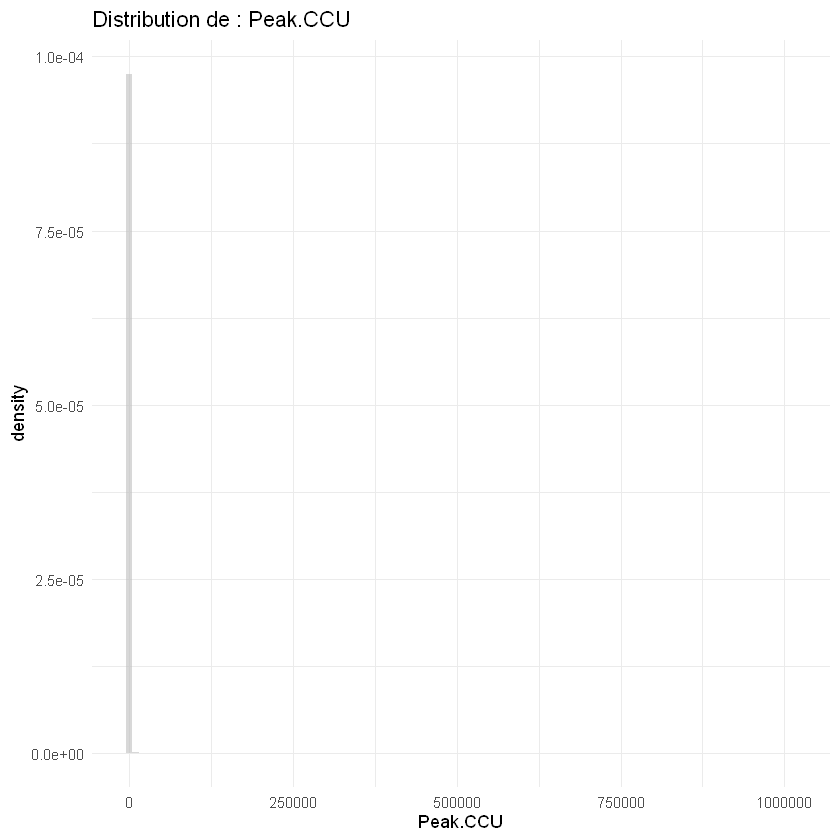

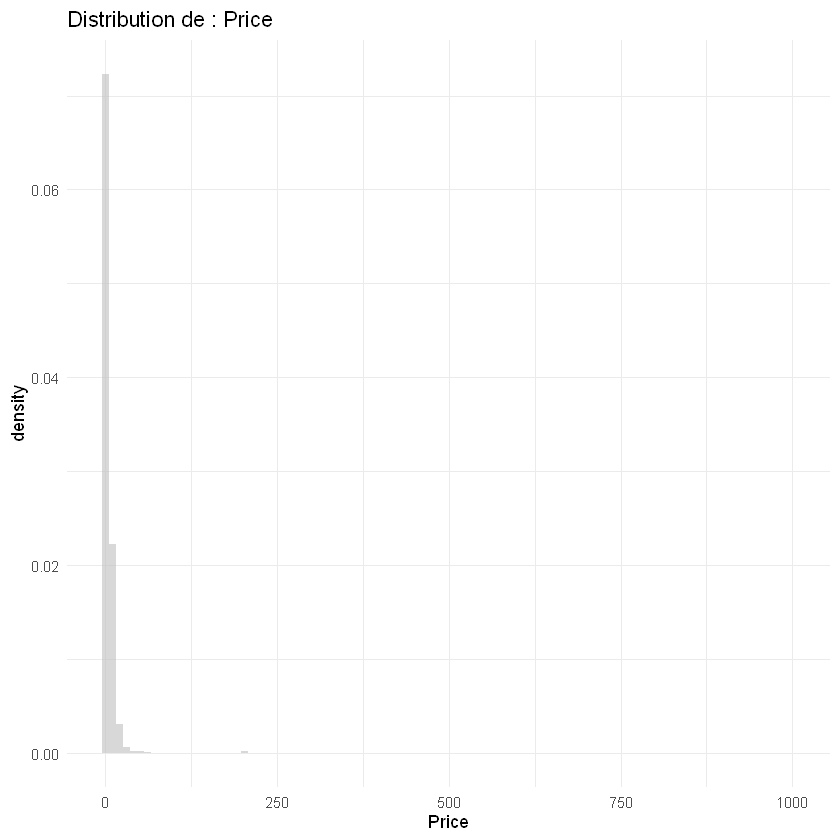

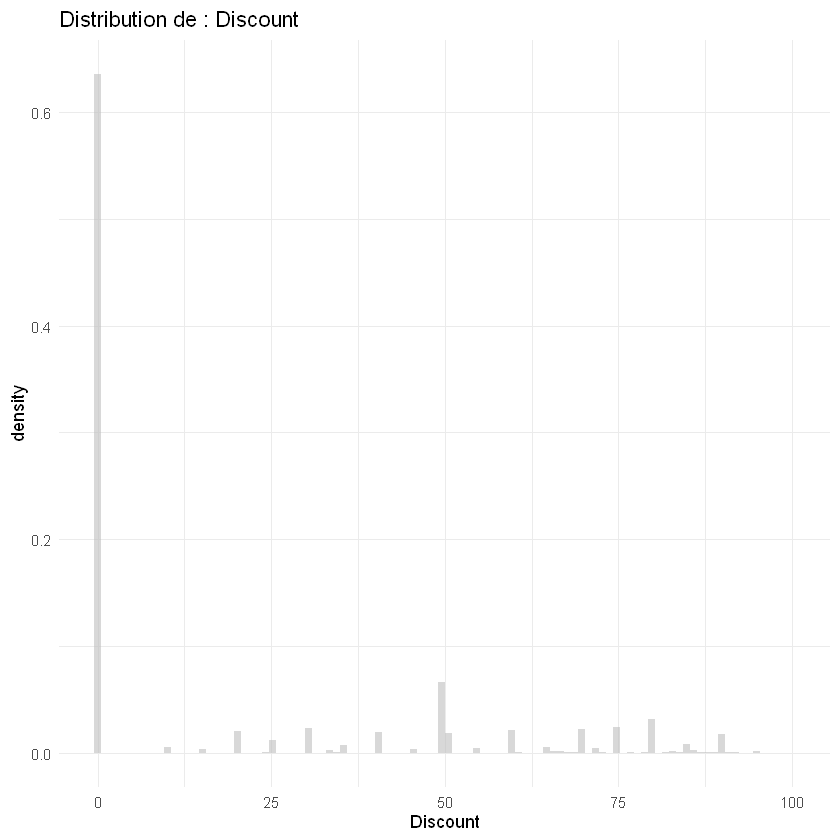

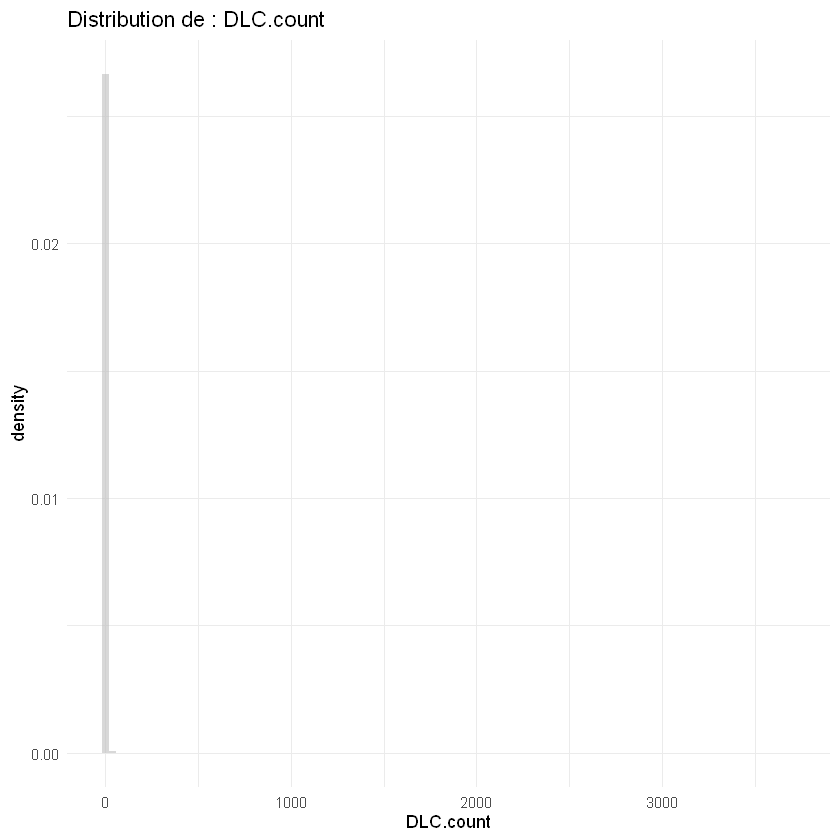

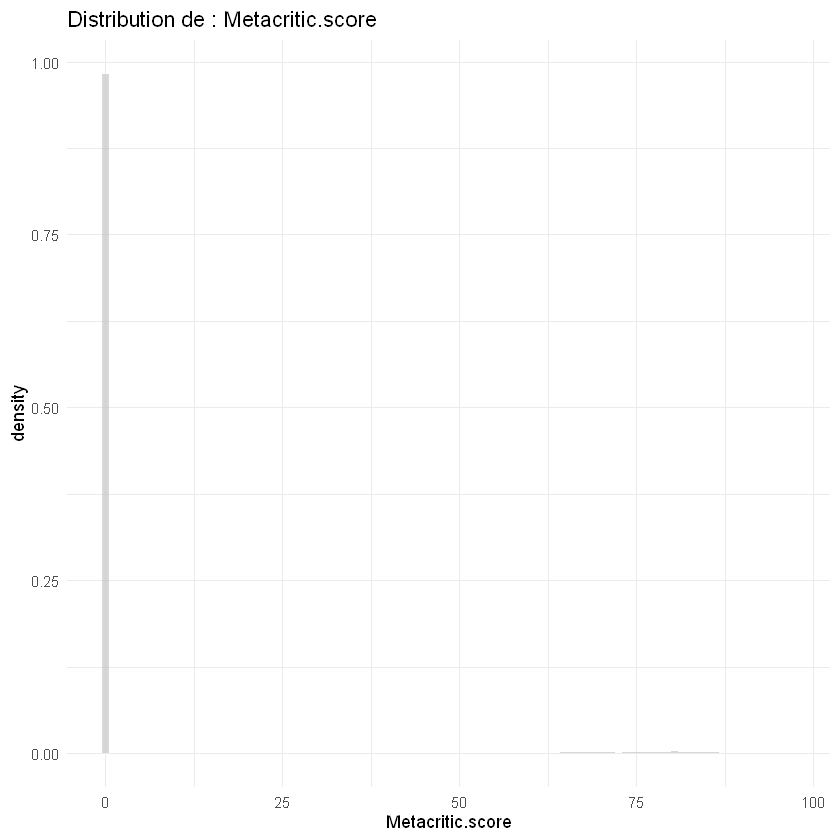

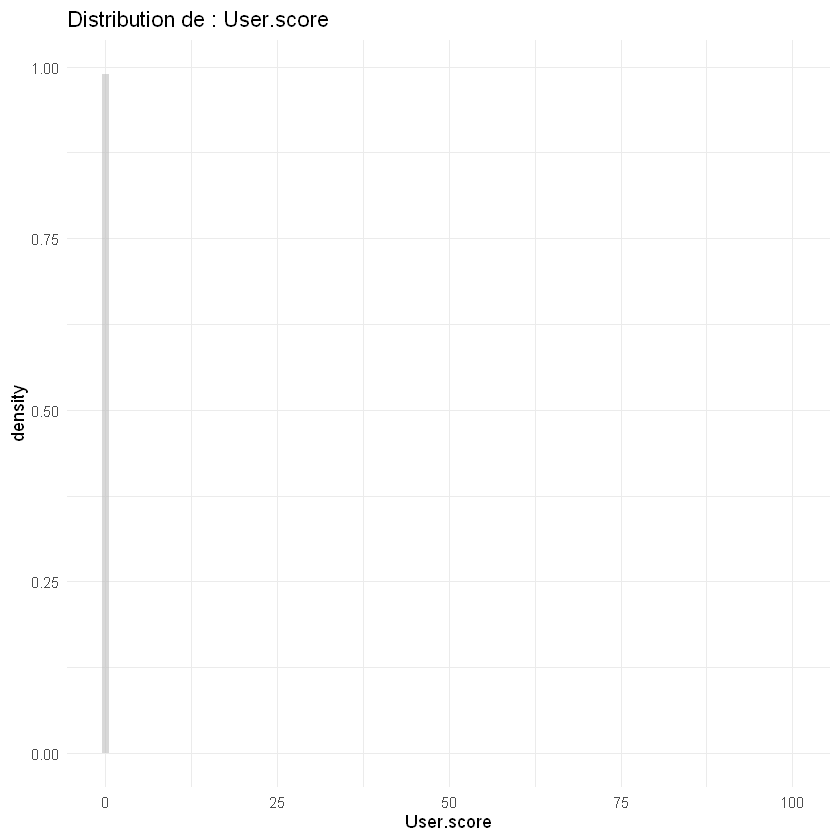

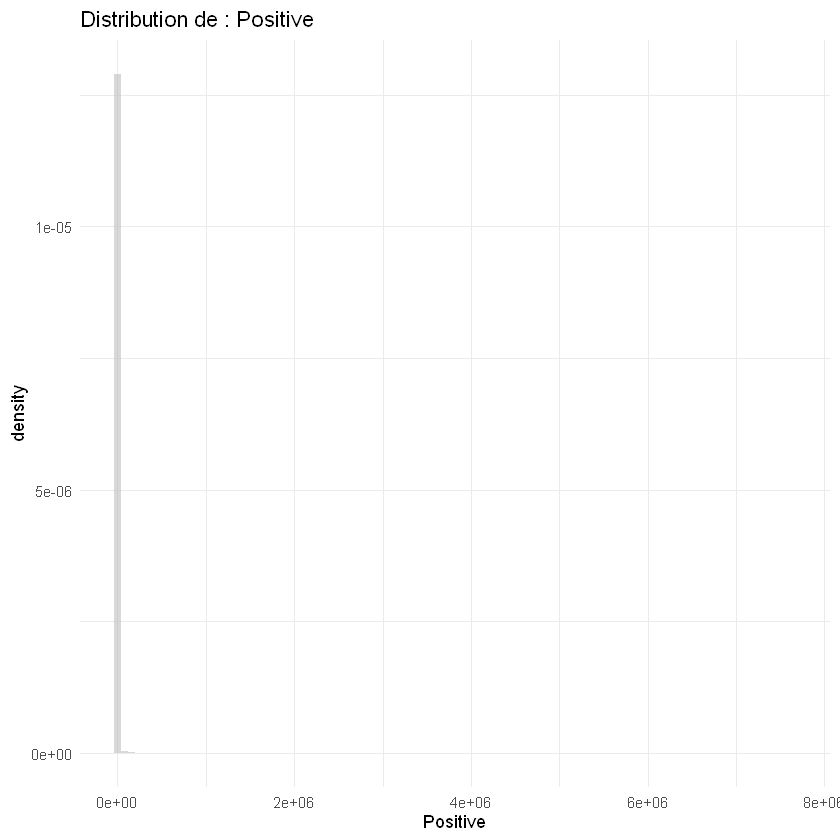

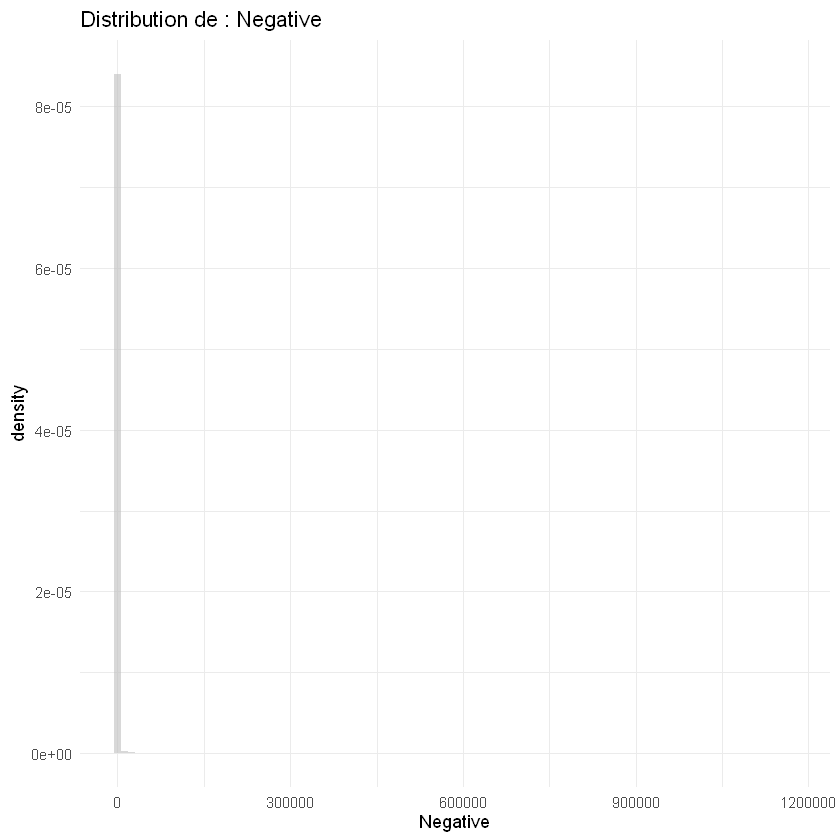

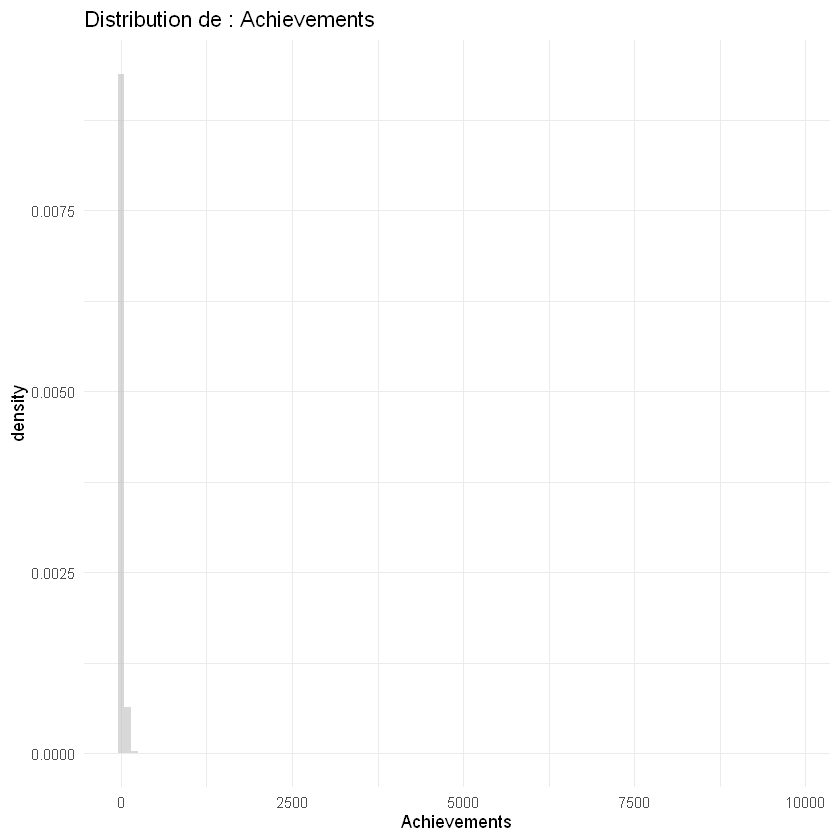

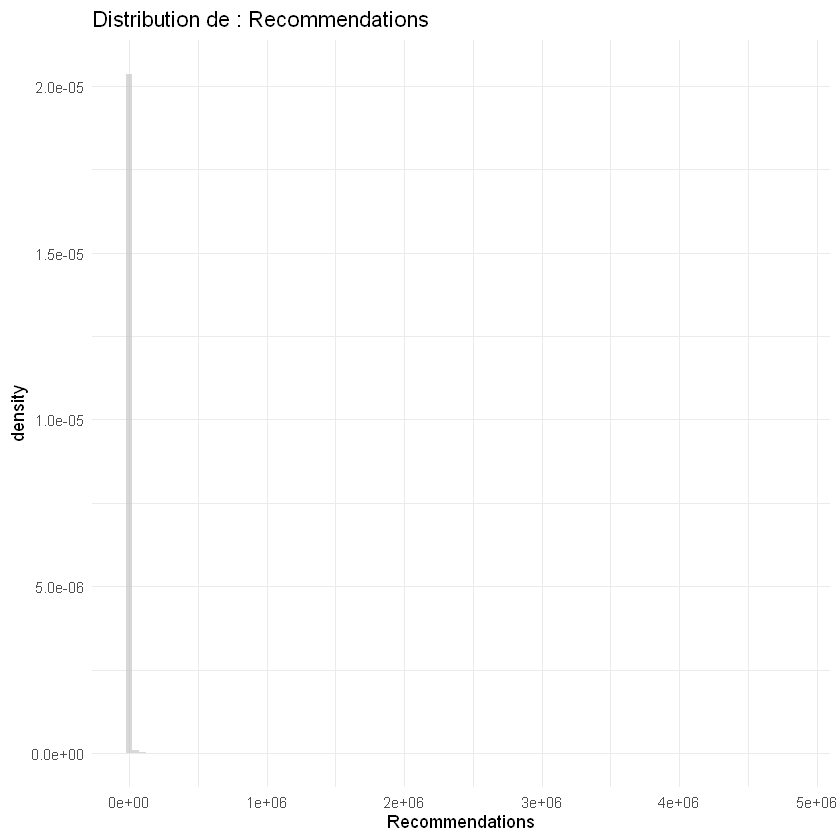

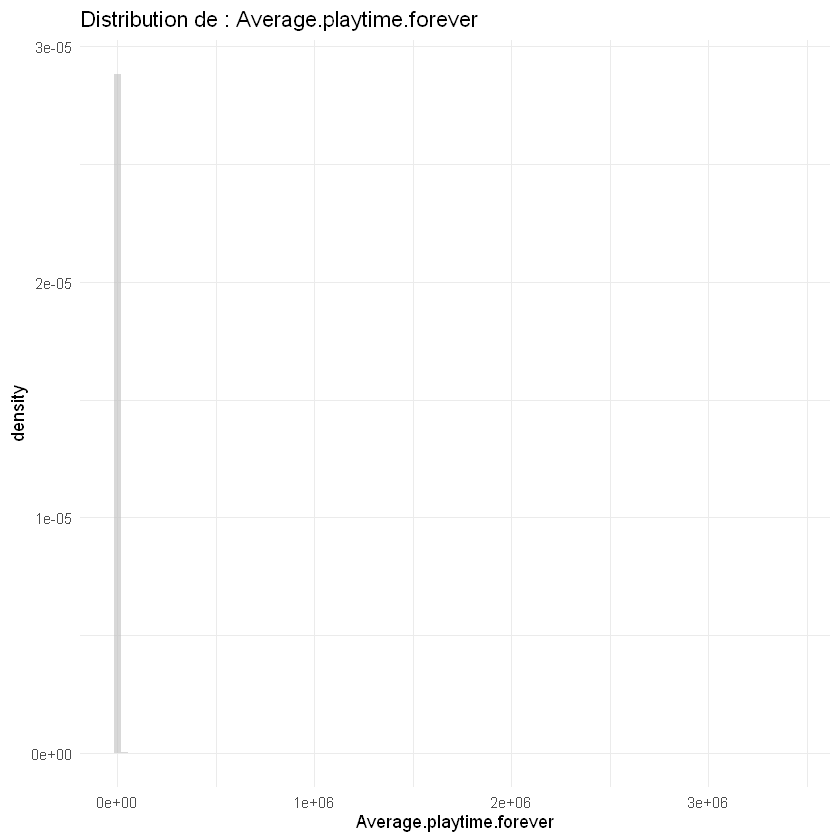

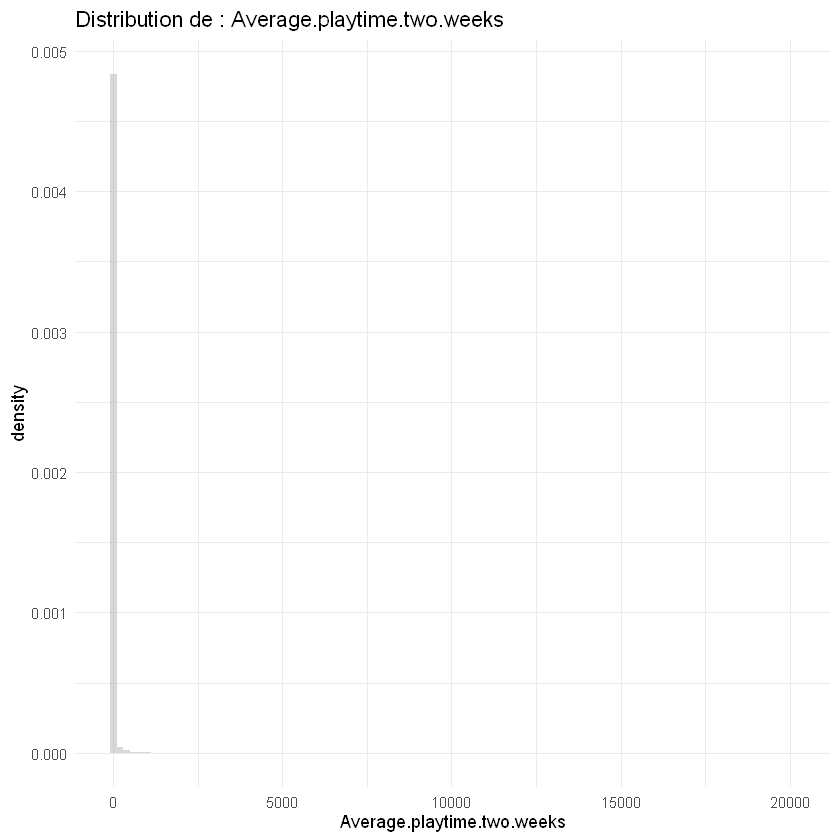

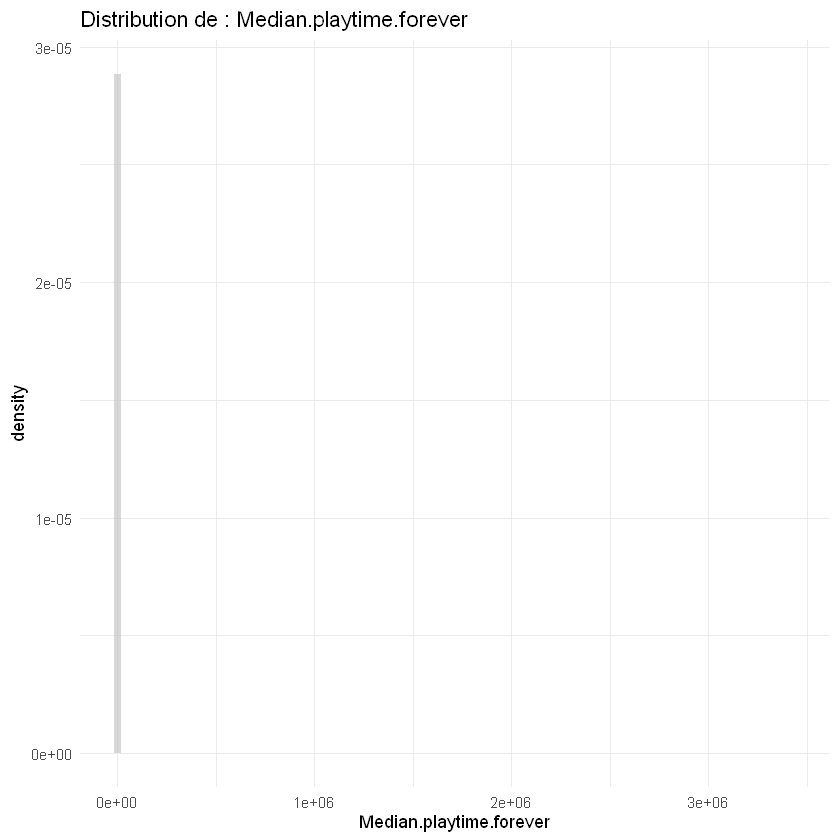

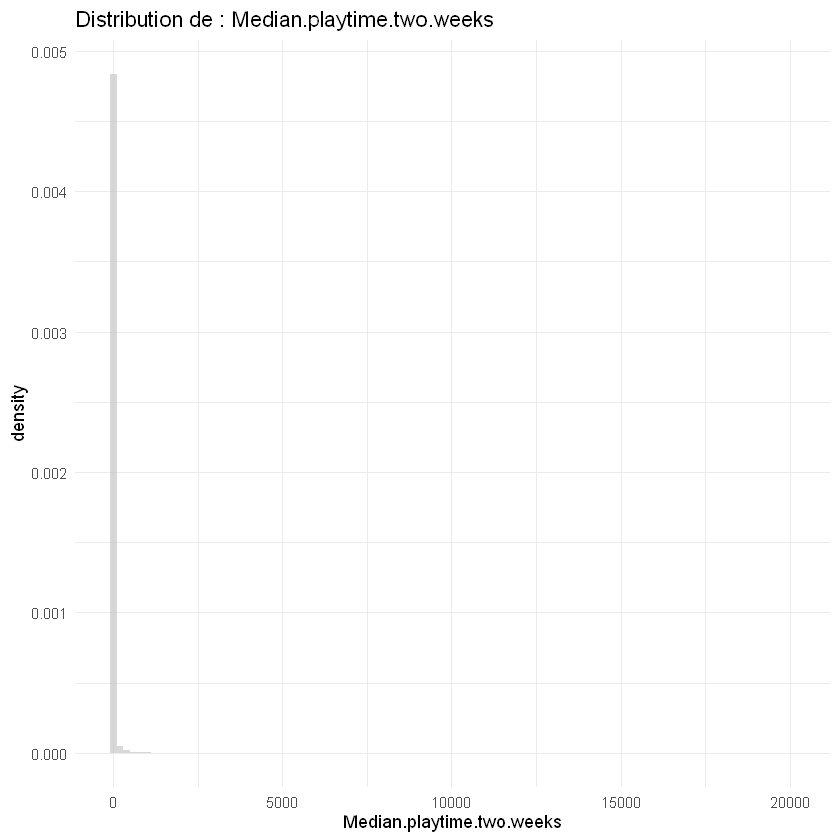

In [34]:

for (col in colnames(data_filtered)) {
  # On vérifie si la colonne est est celle d'une variable quantitatives
  if(is.numeric(data_filtered[[col]])) {
    
    p <- ggplot(data_filtered, aes(x = .data[[col]])) +
      geom_histogram(aes(y = after_stat(density)), alpha = 0.6, fill = "gray",bins=100) +
      theme_minimal() +
      labs(title = paste("Distribution de :", col))
    
    print(p)
  }
}

Puisque nous n'avons pas encore filtré les variables et que pour beaucoup de jeux les valeurs sont à 0 on va faire une transformation en log.

In [42]:
data_log=data_filtered
data_log[,"LPeak.CCU"]=log(1+data_log[,"Peak.CCU"])
data_log[,"LPrice"]=log(1+data_log[,"Price"])
data_log[,"LDiscount"]=log(1+data_log[,"Discount"])
data_log[,"LDLC.count"]=log(1+data_log[,"DLC.count"])
data_log[,"LMetacritic.score"]=log(1+data_log[,"Metacritic.score"])
data_log[,"LUser.score"]=log(1+data_log[,"User.score"])
data_log[,"LPositive"]=log(1+data_log[,"Positive"])
data_log[,"LNegative"]=log(1+data_log[,"Negative"])
data_log[,"LAchievements"]=log(1+data_log[,"Achievements"])
data_log[,"LRecommendations"]=log(1+data_log[,"Recommendations"])
data_log[,"LAverage.playtime.forever"]=log(1+data_log[,"Average.playtime.forever"])
data_log[,"LAverage.playtime.two.weeks"]=log(1+data_log[,"Average.playtime.two.weeks"])
data_log[,"LMedian.playtime.forever"]=log(1+data_log[,"Median.playtime.forever"])
data_log[,"lMedian.playtime.two.weeks"]=log(1+data_log[,"Median.playtime.two.weeks"])


In [43]:
data_log <- data_log %>% select(-c(Peak.CCU,Price,Discount,DLC.count,Metacritic.score,User.score,Positive,Negative,Achievements,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks))

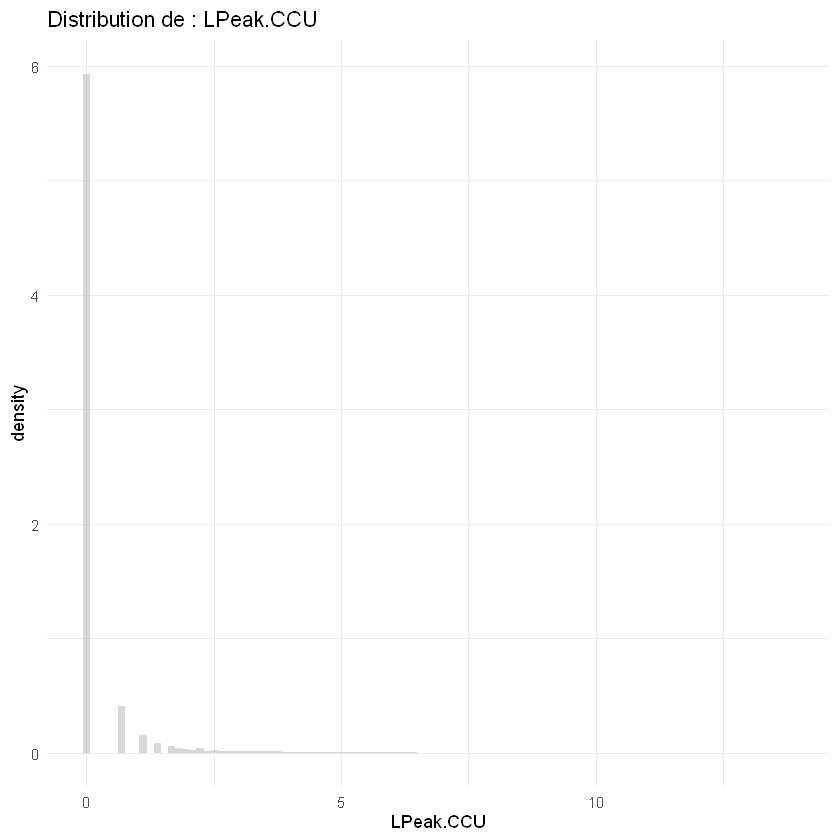

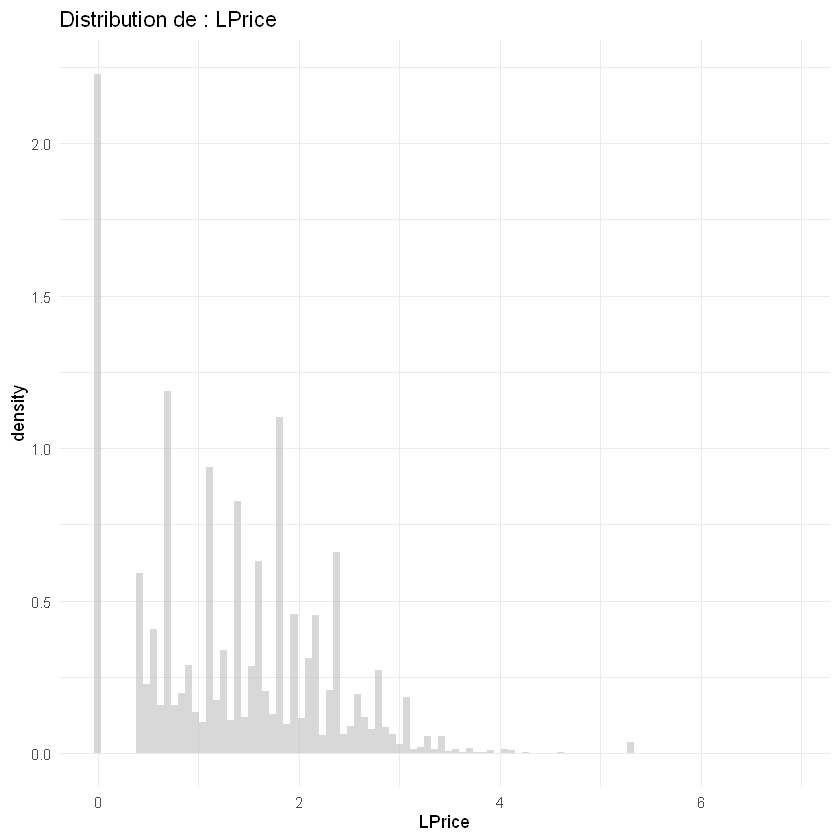

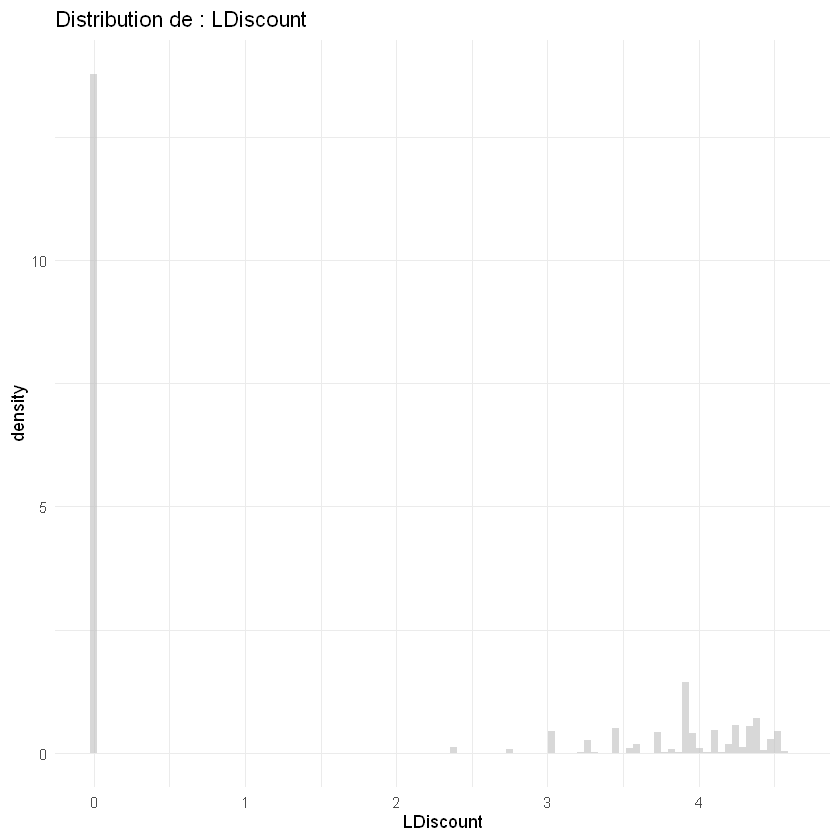

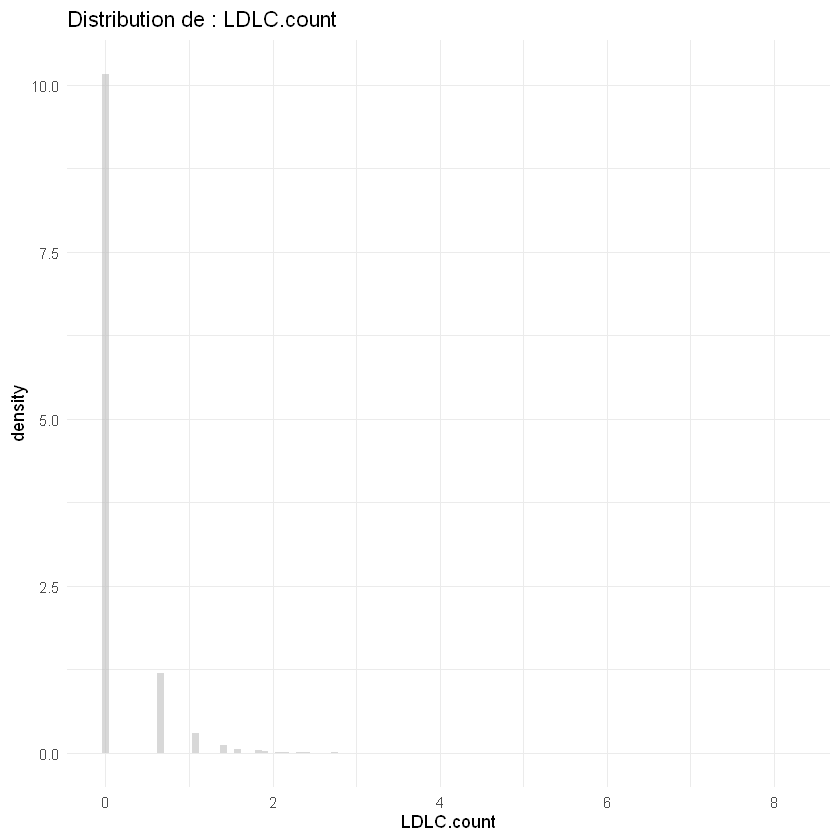

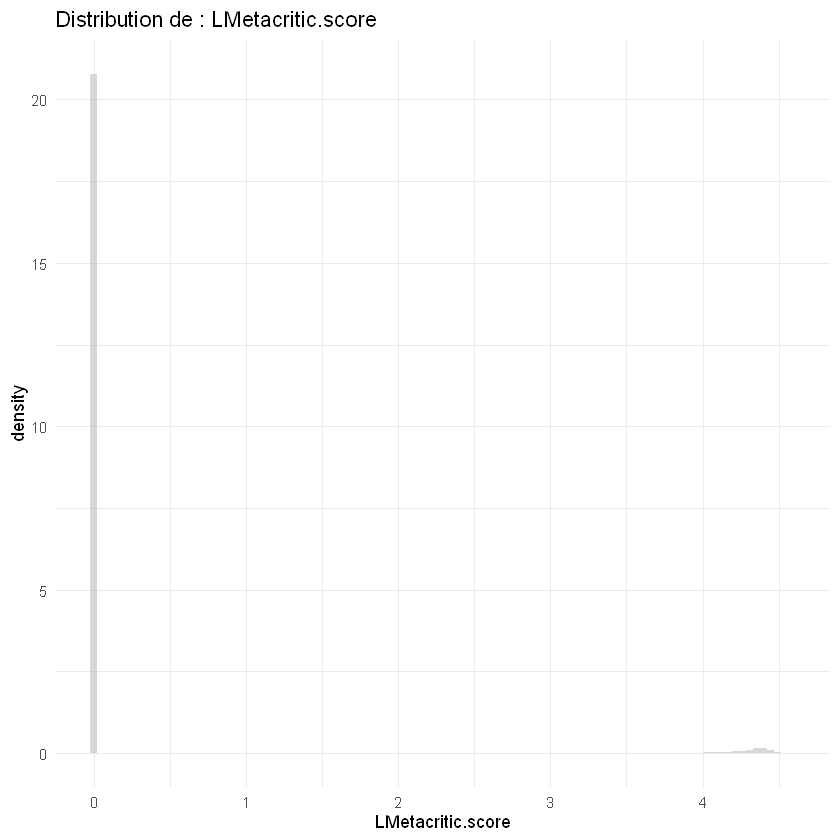

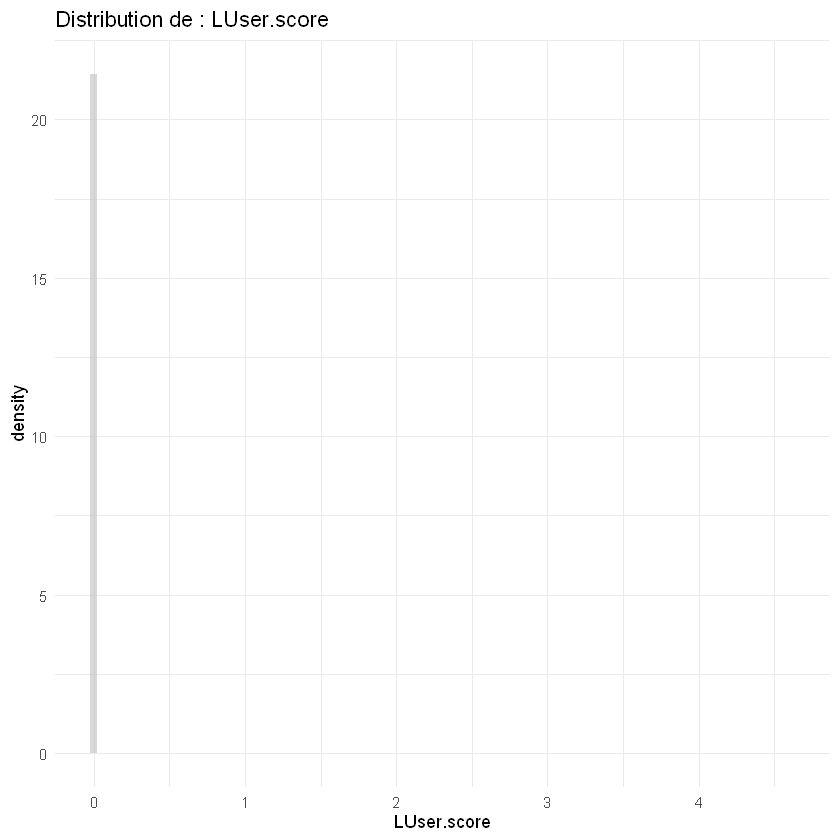

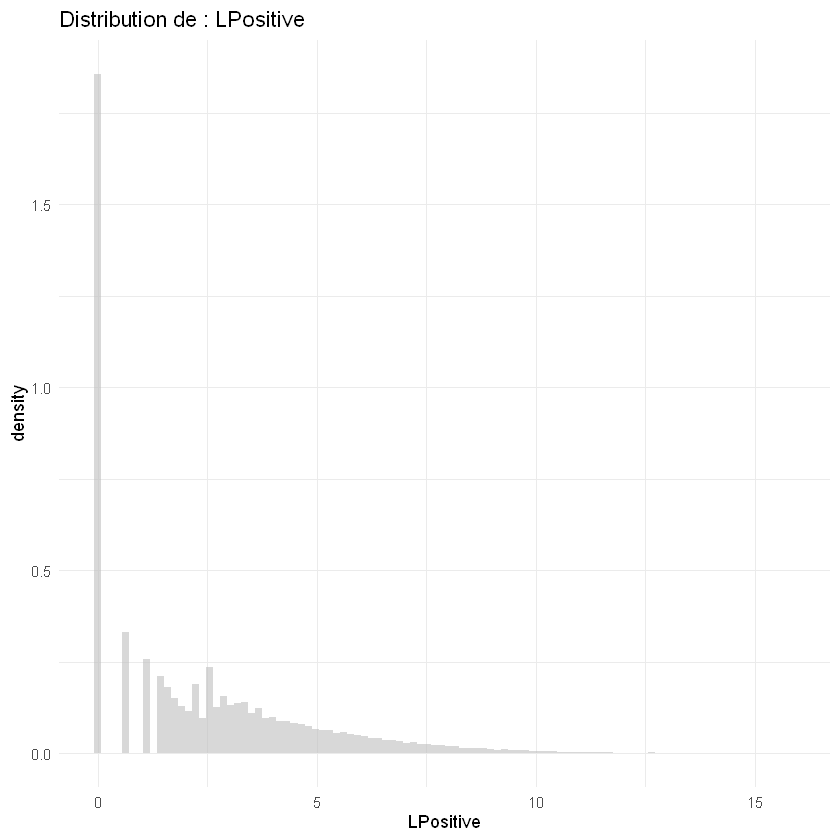

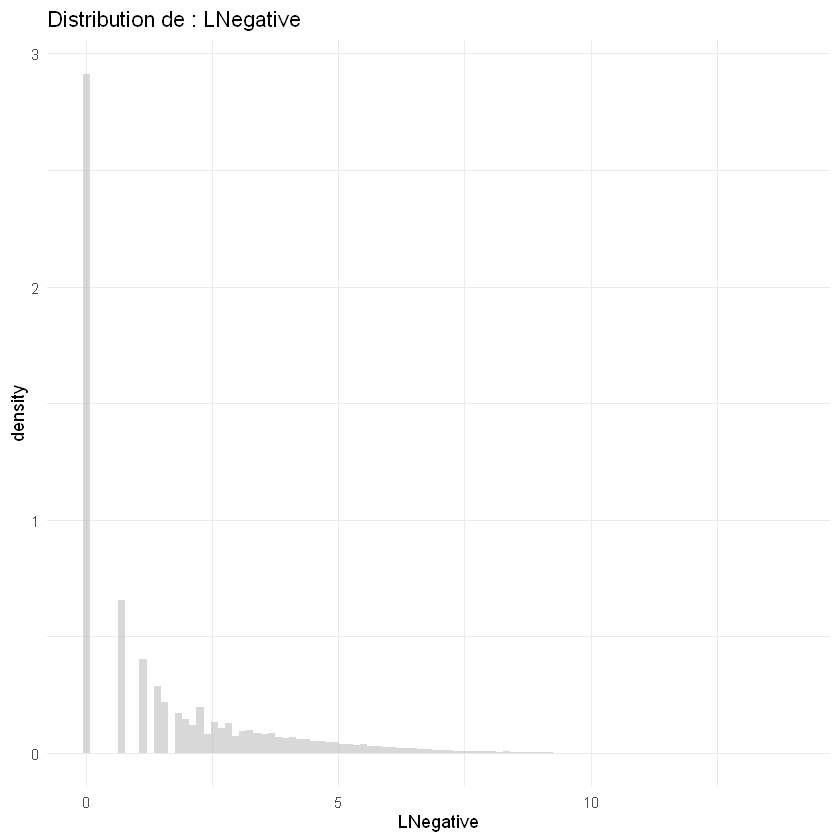

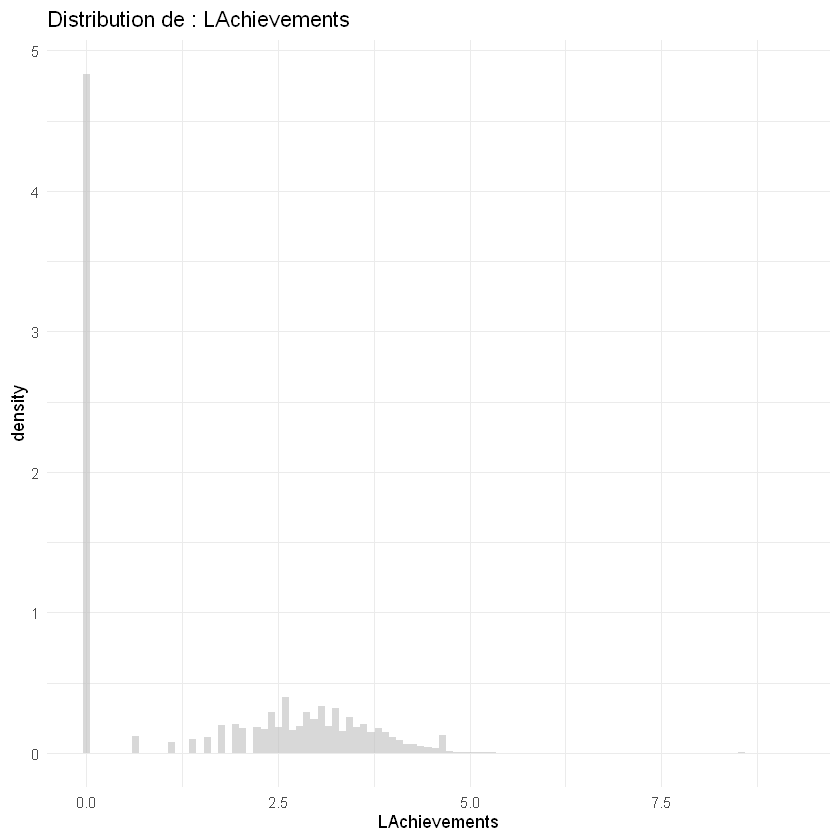

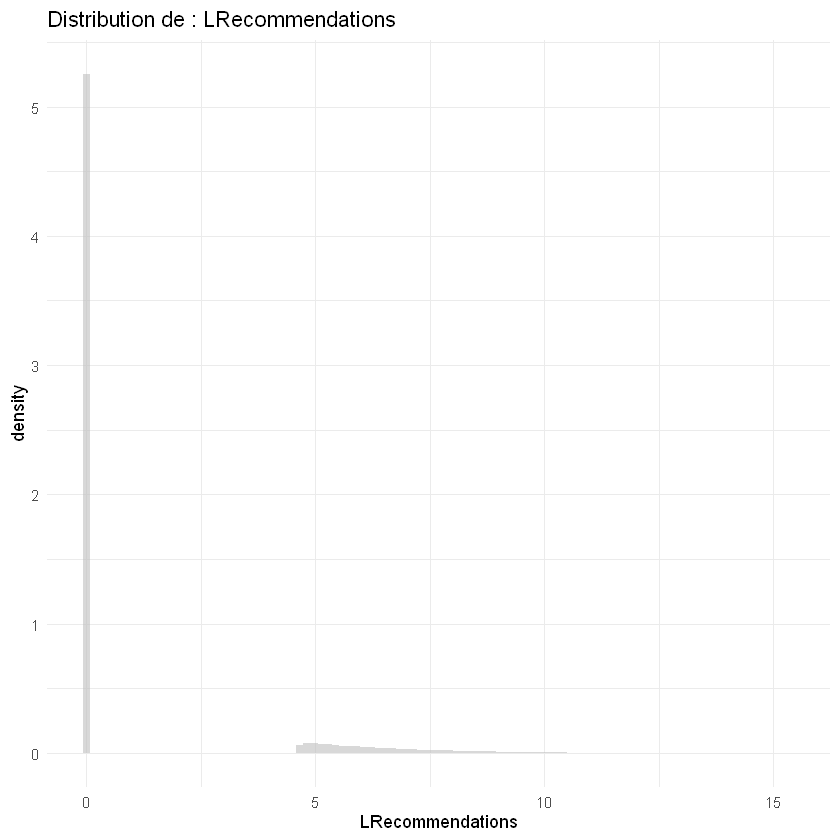

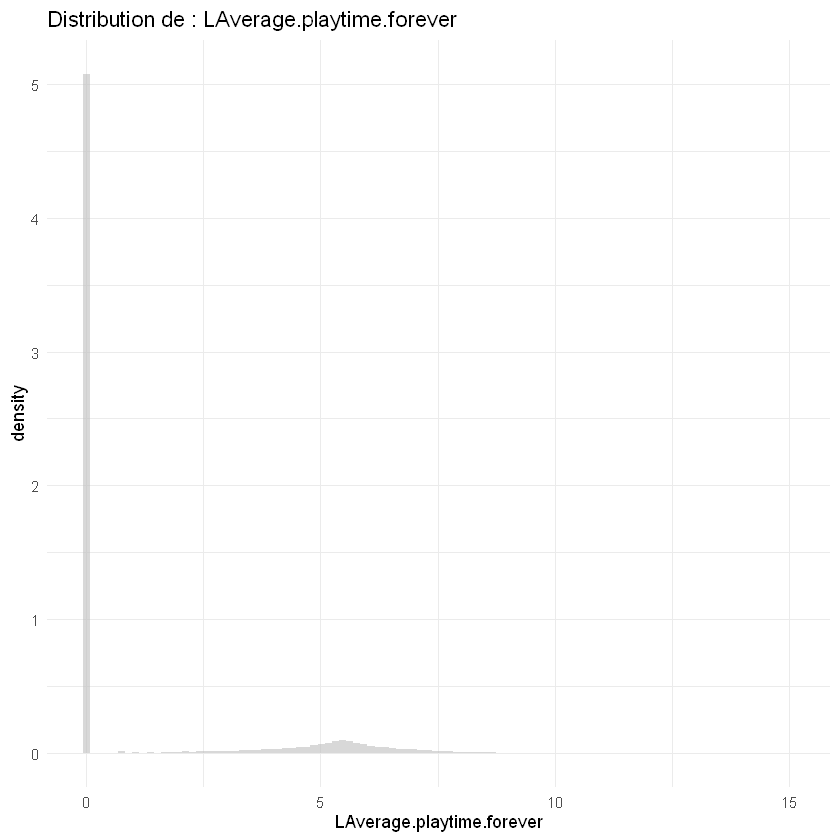

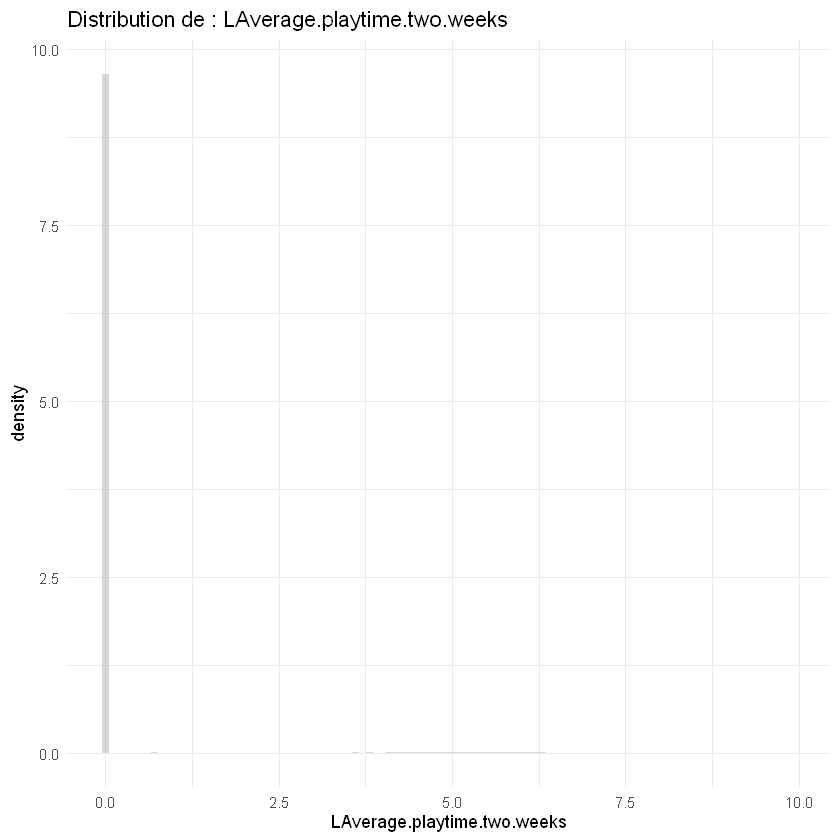

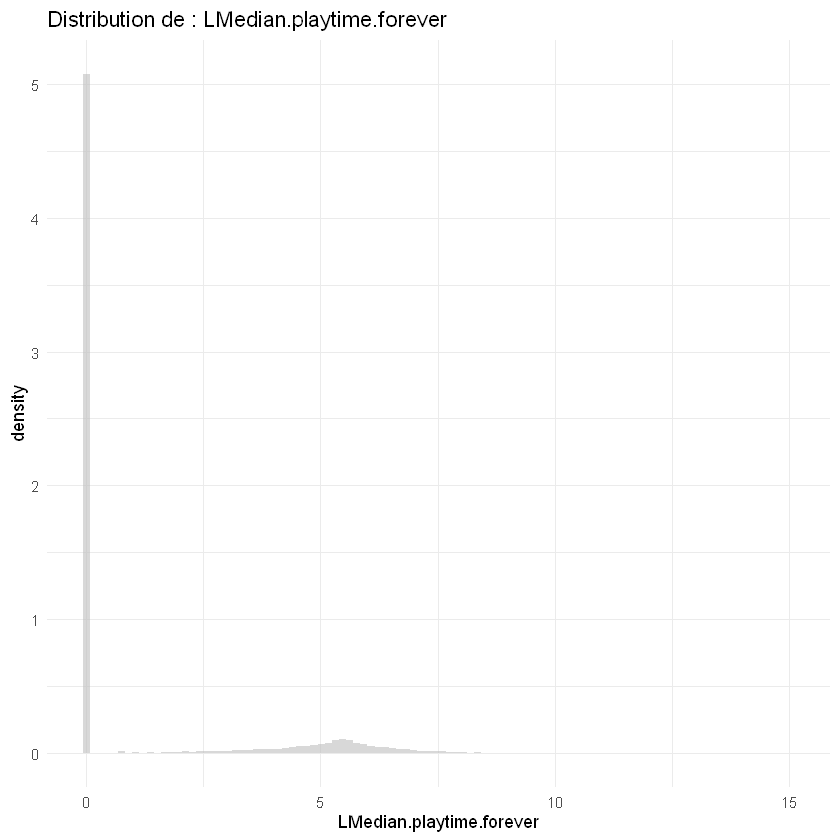

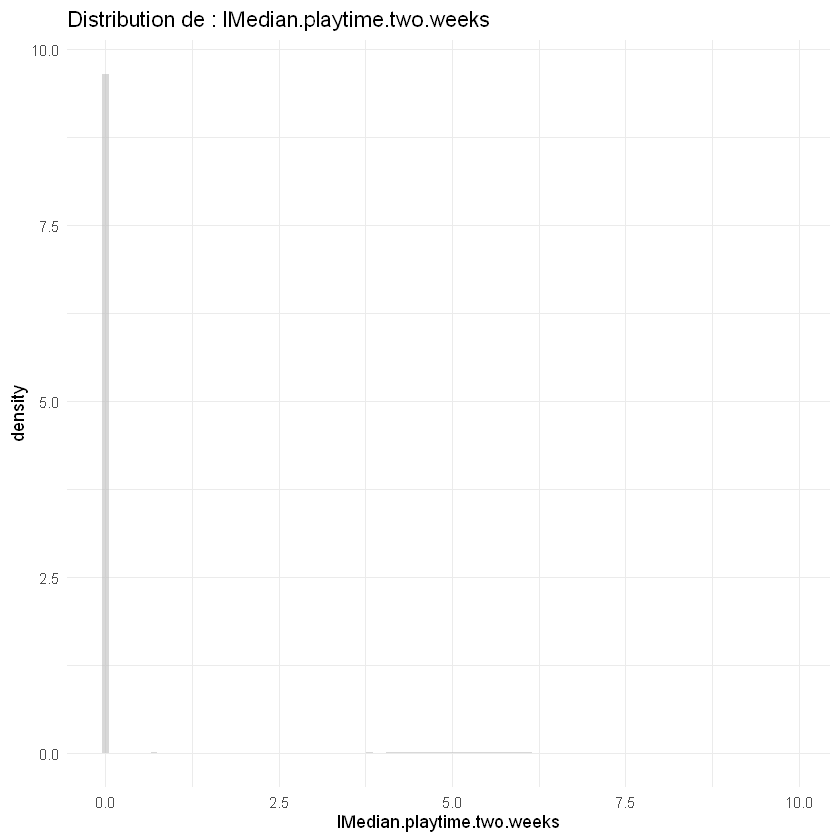

In [44]:
for (col in colnames(data_log)) {
  # On vérifie si la colonne est est celle d'une variable quantitatives
  if(is.numeric(data_log[[col]])) {
    
    p <- ggplot(data_log, aes(x = .data[[col]])) +
      geom_histogram(aes(y = after_stat(density)), alpha = 0.6, fill = "gray",bins=100) +
      theme_minimal() +
      labs(title = paste("Distribution de :", col))
    
    print(p)
  }
}

**A compléter** avec ce qu'on avait vu sur le notebook de jocelin.

Donc même en essayant de transformer les données, on se rends compte que les variables ne sont pas lisibles tant que l'on ne filtre pas les données: c'est à dire de supprimer les individus qui ont des valeurs nulles.

# Variables qualitatives

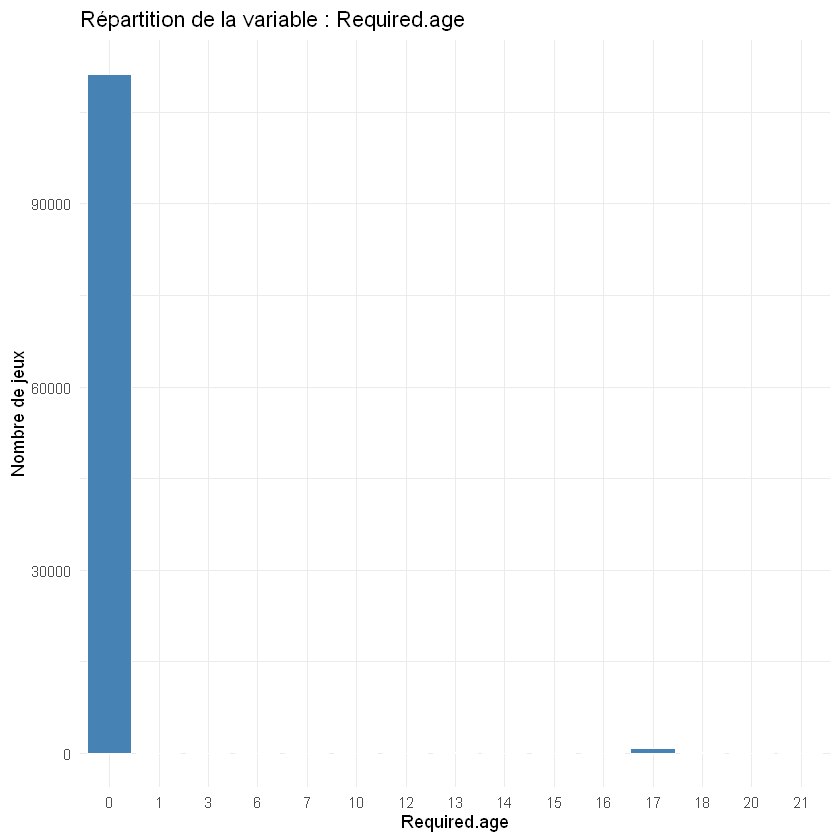

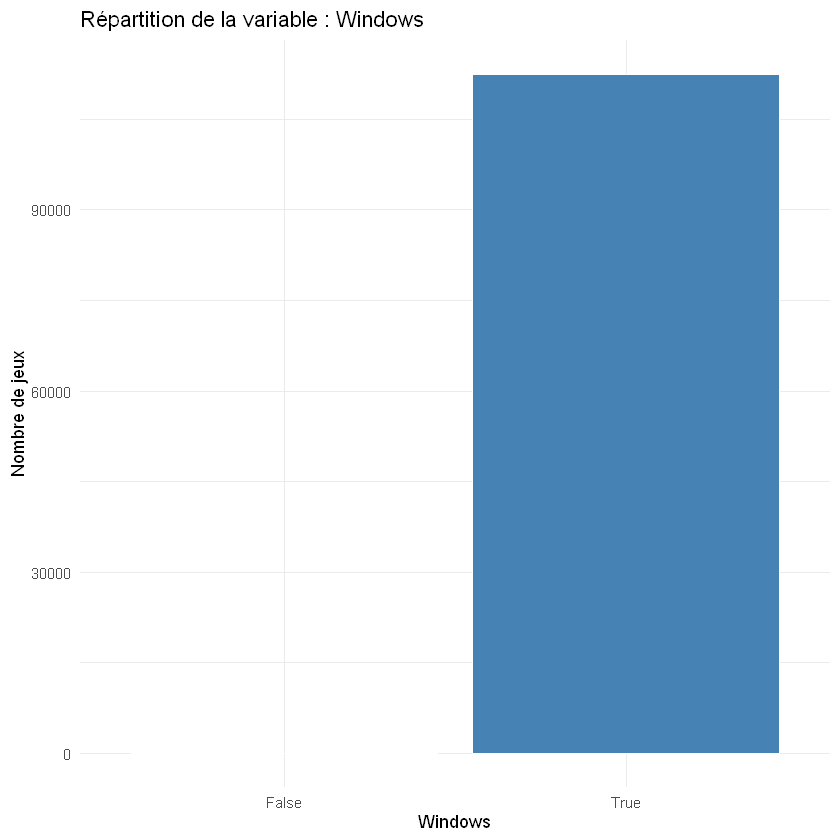

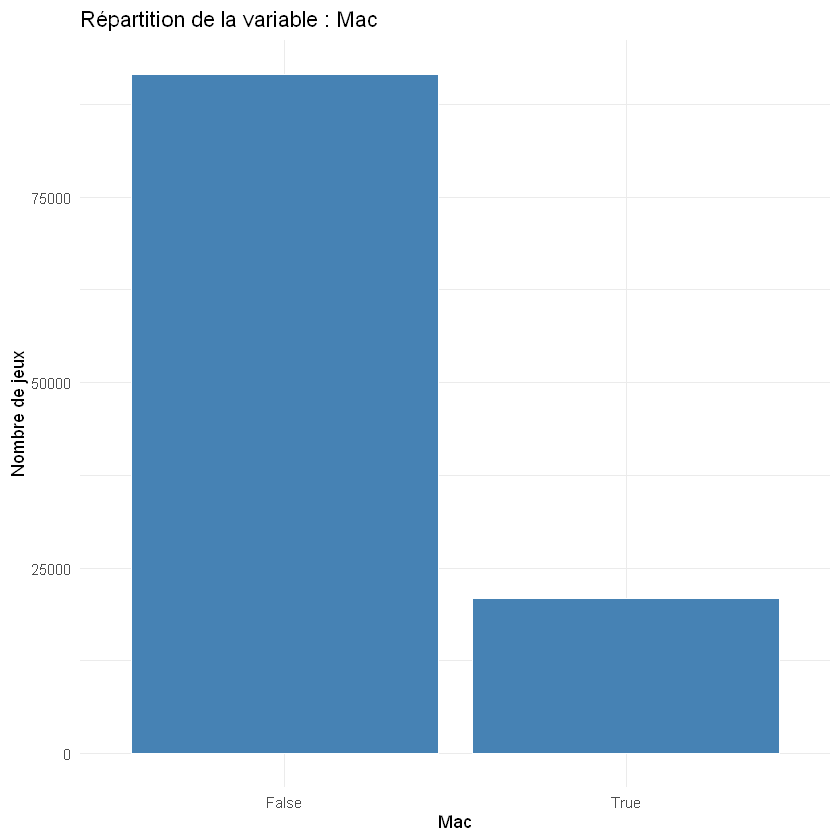

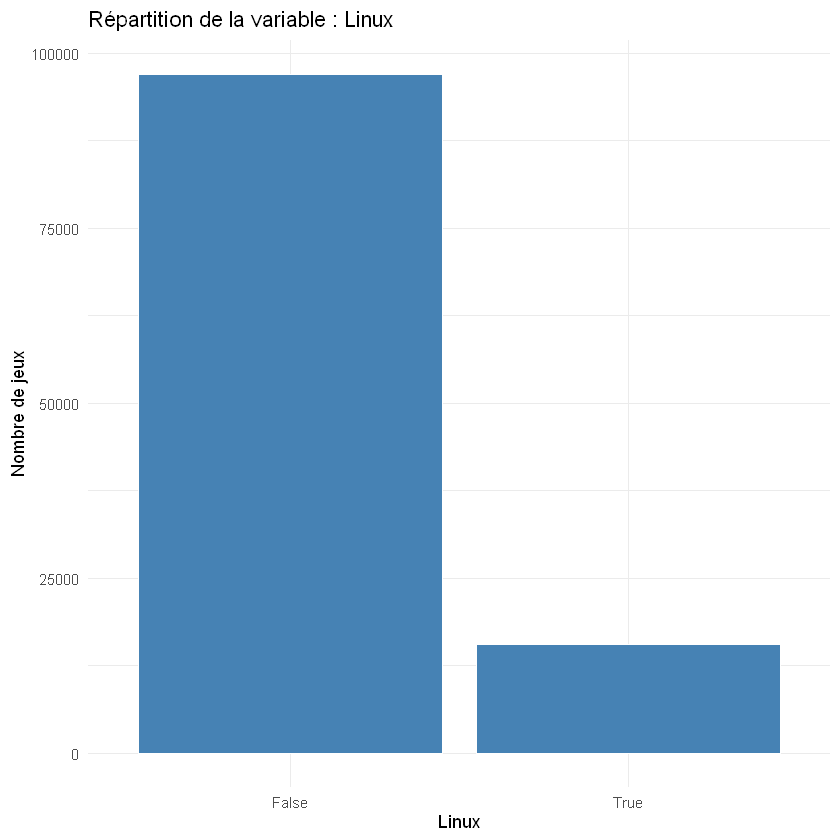

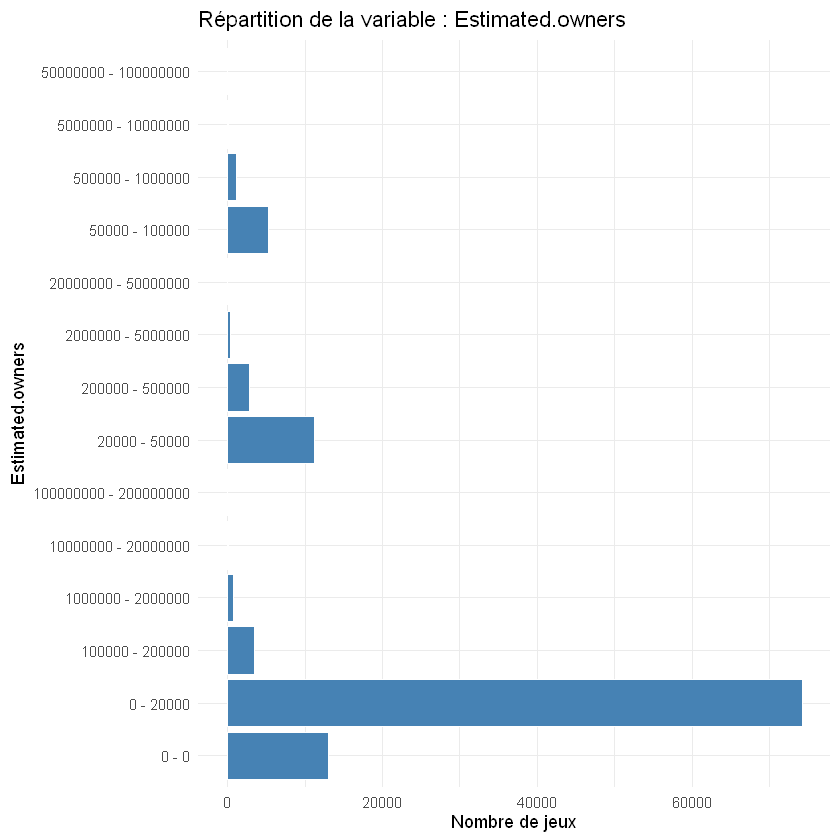

In [55]:

# On définit la liste de TES variables (car is.factor risque de rater le coche)
colonnes_qualitatives <- c("Required.age", "Windows", "Mac", "Linux", "Estimated.owners")

for (col in colonnes_qualitatives) {
    # On utilise geom_bar() car il compte les lignes automatiquement
    p <- ggplot(data_filtered, aes(x = .data[[col]])) +
      geom_bar(fill = "steelblue", color = "white") +
      theme_minimal() +
      labs(
        title = paste("Répartition de la variable :", col),
        x = col,
        y = "Nombre de jeux"
      )
    
    # Gestion spécifique pour la lisibilité des owners
    if (col == "Estimated.owners") {
      p <- p + coord_flip()
    }
    
    print(p)

}

Pour les variables qualitatives, nous pouvons conclure que la quasi-totalité des jeux sont disponible sur Windows et seulement qu'une petite partie sur Windows et Linux.
De plus, il n'y a que très peu de jeux qui qui ont beaucoup d'utilisateurs, la plupart ont entre 0 et 20 000 déteneurs du jeu.
Enfin, on remarque que très peu de jeux ont des restriction d'âge

 **Etude qu'on peut faire**: 
 - quels sont les individus(jeux) qui sont présent sur linux et Mac,peut etre les jeux qui sont les plus connus
 - est- ce que les jeux qui ont des restriction d'age marche mieux ou moins bien que les jeux sans?
 - ...

# Filtrage

## Etude variables par variables: gestion et suppression outliers

### Etude sur la variable supported.language

In [58]:
head(data_filtered[,"Supported.languages"])

[1] "['English']"                                                                                                           
[2] "['English', 'French', 'German', 'Russian']"                                                                            
[3] "['Korean']"                                                                                                            
[4] "['English']"                                                                                                           
[5] "['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']"
[6] "['English']"

Plutôt que de garder la variable supported.languages qui ne contient que des chaines de caractère. On peut plutôt étudier le nombre de jeu supporté par chaque langue (première cellule) ou par jeux le nombre de langue supporté et est ce que ça à une influence sur la note du jeu ou autre chose (deuxième cellule).

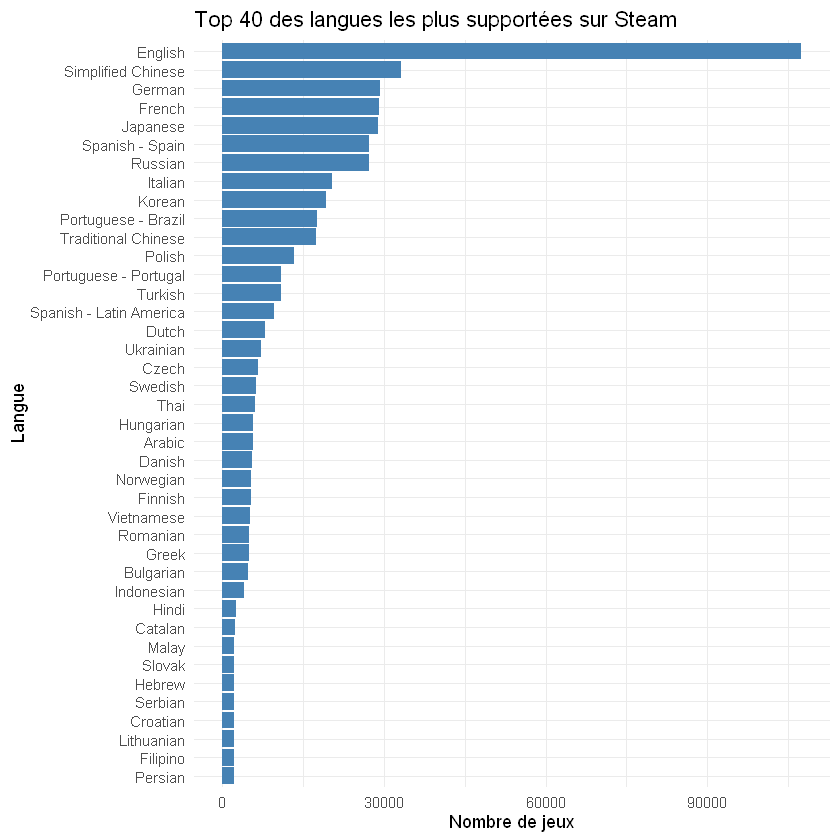

In [59]:
stats_langues <- data_filtered %>%
  # 1. On nettoie les symboles parasites [ ] ' "
  mutate(clean_txt = str_remove_all(Supported.languages, "\\[|\\]|'|\"")) %>%
  # 2. On "éclate" les listes : si un jeu a 3 langues, ça crée 3 lignes
  separate_rows(clean_txt, sep = ",\\s*") %>%
  # 3. On compte combien de fois chaque langue apparaît
  count(clean_txt, sort = TRUE) %>%
  # 4. On garde les 50 premières (en enlevant les vides)
  filter(clean_txt != "" & !is.na(clean_txt)) %>%
  head(40)


ggplot(stats_langues, aes(x = reorder(clean_txt, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # Pour mettre les noms à l'horizontale 
  labs(
    title = "Top 40 des langues les plus supportées sur Steam",
    x = "Langue",
    y = "Nombre de jeux"
  ) +
  theme_minimal()

In [61]:
data_filtered <- data_filtered|>
  mutate(nb_language_supported = case_when(          
    TRUE ~ str_count(Supported.languages, ",") + 1  
  ))
head(data_filtered$nb_language_supported)

[1] 1 4 1 1 9 1

### Etude des variables developers et publishers

Je propose de faire de même pour les variables developers et publishers: c'est à dire de regarder si la note du jeu a un lien avec sont studio de développement et son publieur. J'ai converti les chaines de caractères en minuscule et envelevé les points car dans un premier temps j'ai vu que certains chaines de caractère étaient la même mais juste en majuscule .

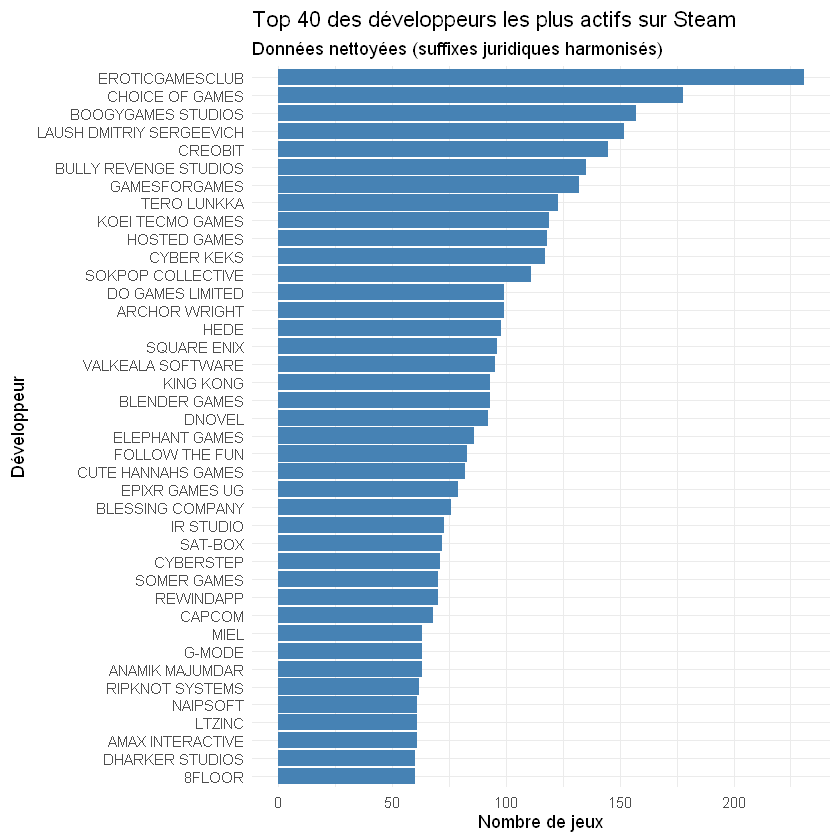

In [62]:

# 1. On définit la liste des suffixes à nettoyer (le "bruit")
# Tu peux en ajouter d'autres ici si tu en vois de nouveaux dans tes données
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")

# On crée le "pattern" de recherche (Regex) : 
# Il cherche ces mots uniquement à la fin de la ligne (d'où le $)
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Traitement du dataset
stat_dev_clean <- data_filtered |>
  # Nettoyage des crochets et guillemets de la liste brute
  mutate(Developers = str_remove_all(Developers, "['\\[\\]]")) |>
  
  # On sépare les jeux en multi-développeurs (une ligne par studio)
  separate_rows(Developers, sep = ",\\s*") |>
  
  # Nettoyage et standardisation
  mutate(
    dev_final = Developers |>
      str_to_upper() |>              # Tout en MAJ pour fusionner (ltd = LTD)
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit)|> # On enlève les suffixes définis plus haut
      str_trim()                     # On enlève les espaces restants
  ) |>
  
  # On évite de compter deux fois le même dev sur un même jeu
  distinct() |>
  
  # On compte et on filtre
  count(dev_final, sort = TRUE) |>
  filter(dev_final != "" & !is.na(dev_final)) |>
  head(40)
  

# 3. Création du graphique
ggplot(stat_dev_clean, aes(x = reorder(dev_final, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 40 des développeurs les plus actifs sur Steam",
    subtitle = "Données nettoyées (suffixes juridiques harmonisés)",
    x = "Développeur",
    y = "Nombre de jeux"
  ) +
  theme_minimal()



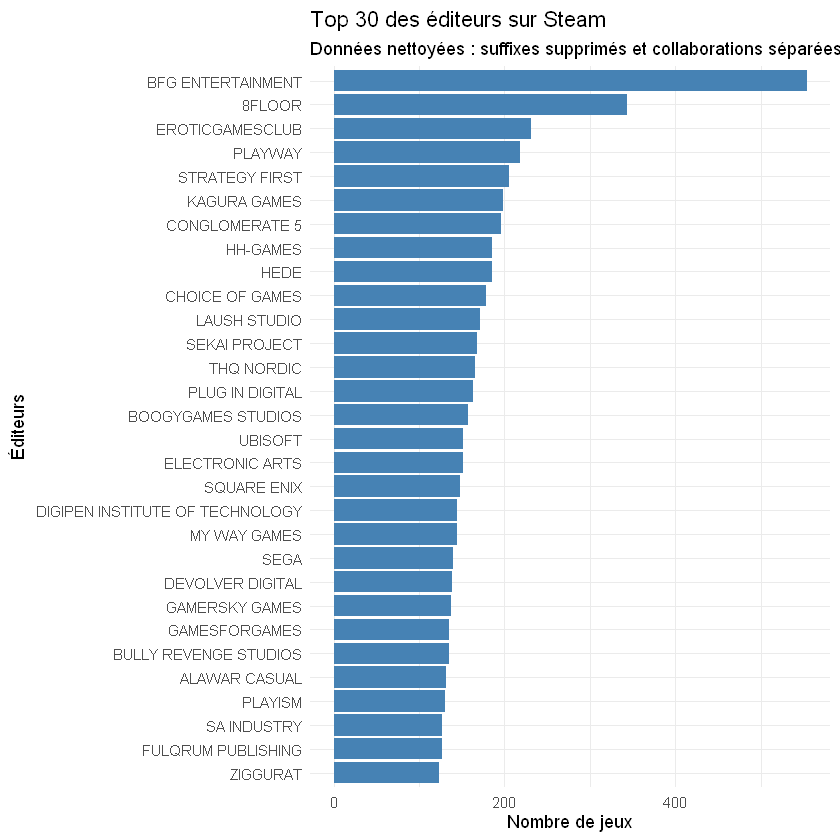

In [63]:

# 1. On définit la liste des suffixes à harmoniser (le "bruit")
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Nettoyage et préparation des données
stat_publisher <-data_filtered |>
  # Nettoyage des symboles de liste et des textes entre parenthèses (ex: (Mac))
  mutate(clean_publ = Publishers |> 
           str_remove_all("['\\[\\]]") |> 
           str_remove_all("\\(.*?\\)")) |> 
  
  # On sépare les co-éditeurs (une ligne par éditeur)
  separate_rows(clean_publ, sep = ",\\s*") |>
  
  # STANDARDISATION POUSSÉE
  mutate(
    clean_publ = clean_publ |>
      str_to_upper() |>              # Tout en MAJUSCULES pour fusionner les variantes
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit) |> # On enlève les suffixes (LTD, LLC...)
      str_trim()                     # On nettoie les espaces restants
  ) |>
  
  # On évite de compter deux fois le même éditeur pour un même jeu (doublons internes)
  distinct() |>
  
  # On compte
  count(clean_publ, sort = TRUE) |>
  filter(clean_publ != "" & !is.na(clean_publ)) |>
  
  # On prend les 30 premiers pour le graphique
  head(30)

# 3. Visualisation moderne
ggplot(stat_publisher, aes(x = reorder(clean_publ, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # On garde coord_flip ou on inverse x et y dans aes()
  labs(
    title = "Top 30 des éditeurs sur Steam",
    subtitle = "Données nettoyées : suffixes supprimés et collaborations séparées",
    x = "Éditeurs",
    y = "Nombre de jeux"
  ) +
  theme_minimal()


### Etude variable release.date

A voir  comment les traiter: en variable qualitative ou autre .

### Etude required.age

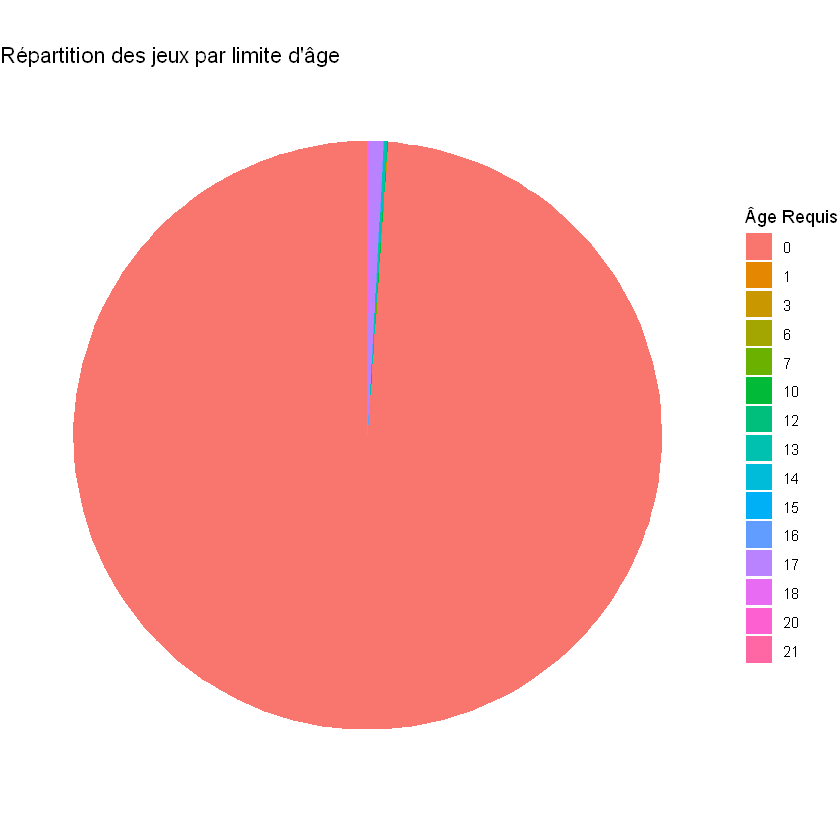

In [64]:
ggplot(data_filtered, aes(x = factor(1),fill = Required.age))+ geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() +
  labs(
    title = "Répartition des jeux par limite d'âge",
    fill = "Âge Requis"
  )

On remarque que les jeux qui n'ont pas de limites sont en grande majorité qui rends la lecture du pie chart compliquée. Il faudrait enlevé cette modalité pour réaliser la stat descriptive. C'est ce qui est fait dans la cellule suivante.

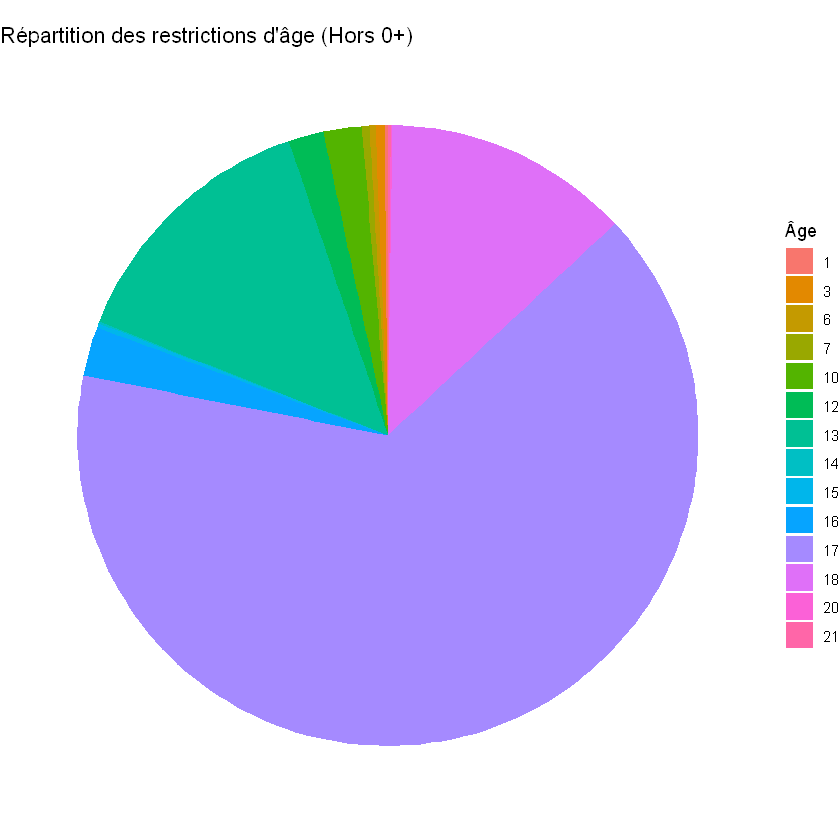

In [65]:


# filtrage de 0
data_age <- data_filtered |> 
  filter(as.character(Required.age) != "0")


ggplot(data_age, aes(x = factor(1), fill = factor(Required.age))) +
  geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() + 
  labs(
    title = "Répartition des restrictions d'âge (Hors 0+)",
    fill = "Âge"
  )

On remarque une majorité de restriction pour les moins de 17 ans.

# Traitement des outliers

In [66]:

data2 <- data_filtered[data_filtered$Estimated.owners != "0 - 0", ]

dim(data2)


[1] 99464    29

In [67]:

data2$Positive=data2$Positive+1
data2$Negative=data2$Negative+1


data2[, "LPositive"] <- log(data2[, "Positive"])

data2[, "LNegative"] <- log(data2[, "Negative"])


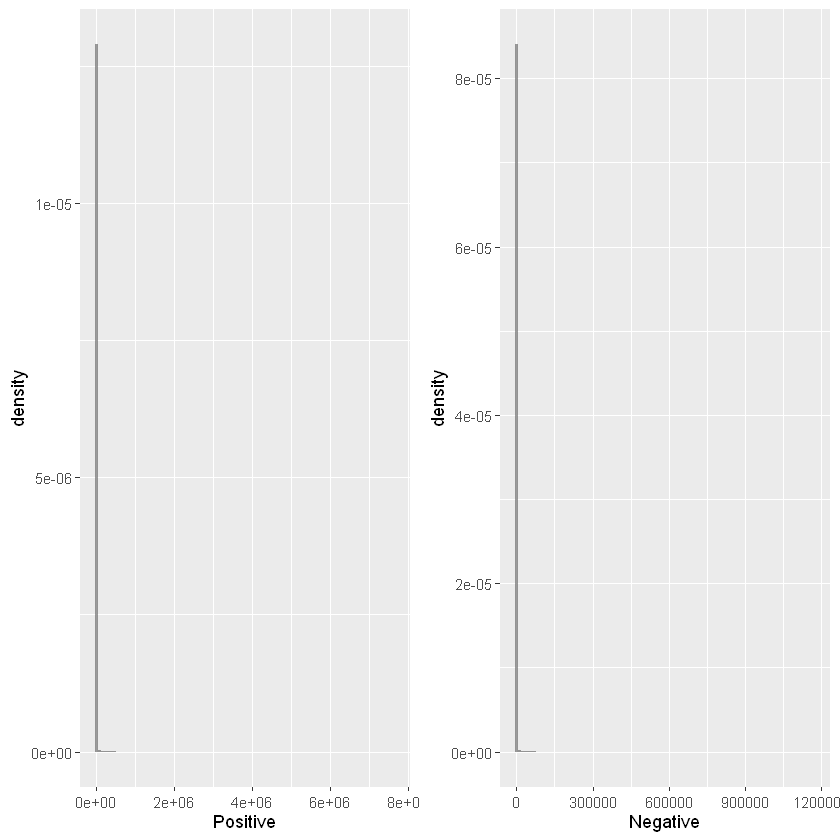

In [68]:
g1<-ggplot(data1,aes(x=Positive))+ geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=100)
g2<-ggplot(data1,aes(x=Negative)) + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=100)
 grid.arrange(g1,g2,ncol=2)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


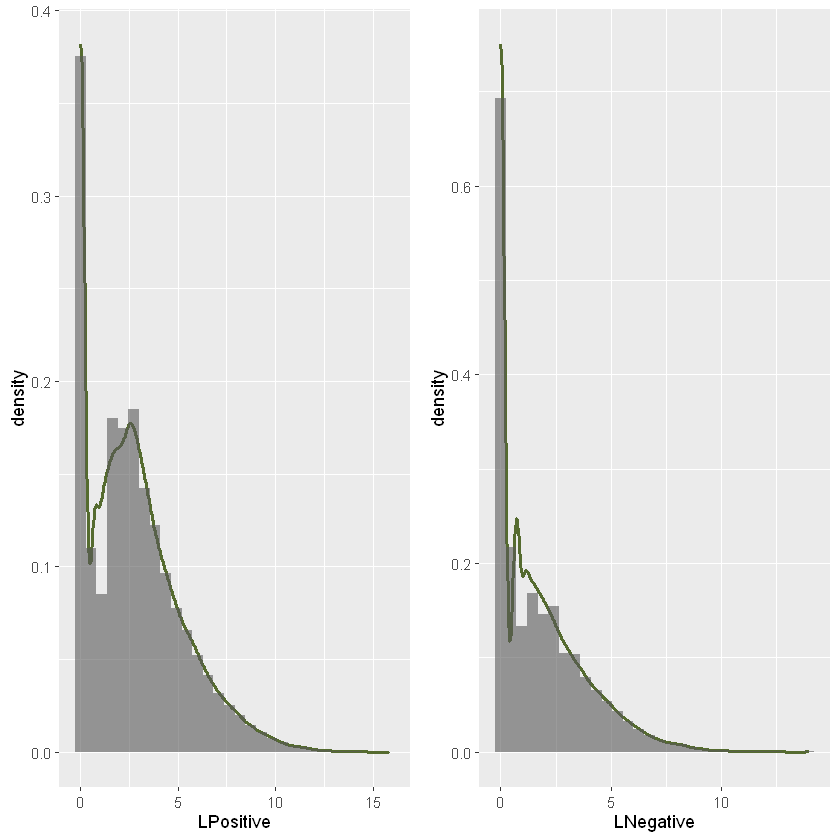

In [69]:



 lg1<-ggplot(data2,aes(x=LPositive))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
 lg2<-ggplot(data2,aes(x=LNegative))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))  

 grid.arrange(lg1,lg2,ncol=2)

On concatène les variables Tags et Genres car on s'est rendu compte que la variables Tags contenait la variable Genres la plus part du temps.

In [ ]:

data3 <- data2 %>%
  # 1. On travaille ligne par ligne
  rowwise() %>%
  
  mutate(
    # 2. On fusionne les deux colonnes
    temp_concat = paste(Tags, Genres, sep = ","),
    
    # 3. On nettoie à l'intérieur de la ligne
    Tags_Genres_Final = temp_concat %>%
      # On découpe par la virgule
      str_split(",") %>%
      # On transforme en vecteur simple
      unlist() %>%
      # On enlève les espaces inutiles
      str_trim() %>%
      # On enlève les vides, les "NA", "NaN", "null" (insensible à la casse)
      .[. != "" & !is.na(.) & !str_detect(tolower(.), "^na$|nan|null")] %>%
      # On garde les valeurs uniques (supprime les doublons entre Tags et Genres)
      unique() %>%
      # On recolle le tout
      paste(collapse = ", ")
  ) %>%
  
  # 4. On repasse en mode normal et on supprime la colonne temporaire
  ungroup() %>%
  select(-temp_concat)
head(data3)


### On enleve les anciennes variables que l'on a modifié

In [ ]:
data4 <- data3 %>% select(-c(Tags,Genres,Positive,Negative))

In [ ]:
summary(data4)

## Etude variariable métacrique score

C'est une variable très importante qu'il faudra exploiter. C'est une note moyenne donnée par des journalistes, des magazines de jeux vidéo et des sites web experts. Cette note est entre 0 et 100 plus on est proche de 100 mieux c'est. Cependant, beaucoup de jeux n'ont pas de note car peux de journaux ont parlé d'eux assez pour que Steam en prenne compte dans une note, donc qu'il est une note different de 0.

In [ ]:

100-(sum(data4$Metacritic.score == 0)/length(data$Metacritic.score))*100

En effet, il y a que 21% des jeux qui ont une note superieur à 0. La question c'est est ce qu'on garde que c'est jeux là pour une étude pour prédire le score metacritic?  

### Etude temps de jeux

In [ ]:
ggplot(data4, aes(x = Average.playtime.forever)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

ggplot(data4, aes(x = Median.playtime.forever)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

In [ ]:
sum(data4$Average.playtime.forever==0)
sum(data4$Median.playtime.forever==0)

On se rend compte que le nombre de jeux qui on un temps de jeux égale à 0 fausse l'étude: on a qu'un seul pic à 0. Aussi, on remarque que l'on a une échelle en x de 1e+06 ce qui veut dire que l'on a aussi des jeux qui ont un temps de jeux énorme donc en plus d'enlever les 0 on va transformer en log les données.

In [ ]:

data5 <- data4 %>%
    filter(
    Average.playtime.forever > 0,         
    Median.playtime.forever > 0
 
  ) %>%
  # 2. On calcule les versions Log
  mutate(
    LAverage_playtime = log(Average.playtime.forever),
    LMedian_playtime = log(Median.playtime.forever)
  ) 

# Visualisation pour vérifier l'effet du Log
ggplot(data5, aes(x = LAverage_playtime)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

ggplot(data5, aes(x = LMedian_playtime)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

Ainsi, on peut se satisfaire de ces graphs.**on pourra supprimerAverage.playtime.forever, Median.playtime.forever et garder la version log**